<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Requirements:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 
Compatible with data_handling.py and fit_FMR_class.py (currently only Generalizing-complex-fits branch)
<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
V Original
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 

In [218]:
import h5py
import numpy as np 
import sys

import matplotlib.pyplot as plt

from pathlib import Path

sys.path.append(r"C:\Users\840 G5\OneDrive - Higher Education Commission\Documents\GitHub\VNA_analysis")
from data_handling import Analysis_FMR, FitStore
import fit_FMR_class as models
import complex_fits as fits
import fitting_functions as funcs
import resonance_functions as res_func

import ipywidgets as widgets
from ipywidgets import interact

from scipy.optimize import curve_fit

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Files Information:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
Fill in the information about the files to be analyzed. Create a class entity for each file with Analysis_PSWS()

In [219]:
#Folders where file are. Keep the r to use raw string in Windows.
address1 = Path(r"E:\FZU_DATA\OneDrive_1_6-8-2026\PtandYIG_new_params\FMR_2026-06-05")

In [220]:
file_name_1 = "2026-06-05_FMR_fsw_0Ato19p5Ain81_0p5to28p5GHz_0dBm_18-40.h5_try.ma8"

In [221]:
sample = "YIG_Jone_FMR"

In [222]:
geometry = "inP" #either "inP" or "outP"

In [223]:
vna_ref_subtracted = True #Was a reference already subtracted during measurements?

In [224]:
ansy1 = Analysis_FMR(address1, file_name_1, sample, "FZU_FMR", geometry, vna_ref_subtracted)

In [225]:
store_in_origin = True #True if you wnat to store fit results in orignal file, otherwise another h5f file is created in the same directory

In [226]:
if store_in_origin:
    newFile = ansy1.file
else:
    newfile_name =  s.replace(".h5.ma8", "_LorentzFits.h5")
    newFile = address1/newfile_name

fits_storage = FitStore (newFile, group="Lorentzian fitting")

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Data visualization:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
plot_dL_slider() allows one to preview the data for each field to select the best reference subraction.

In [227]:
ansy1.plot_dij_slider('d_S', n_0=5)

interactive(children=(IntSlider(value=5, description='Field index', max=80, readout_format='.0f'), Output()), …

In [228]:
#Ref. subtraction

In [229]:
ansy1.subtract_ref(single=False, fit=True, nb_g=1, ref_indx= 0) 
############It is saving a fuuuuull matrix of reference, no good

In [230]:
#Recheck data after new ref

In [231]:
ansy1.plot_dij_slider('d_S', n_0=5)

interactive(children=(IntSlider(value=5, description='Field index', max=80, readout_format='.0f'), Output()), …

In [232]:
# Example of a single fit

{'Ar': -7.191224428252678e-05, 'Ai': 8.793311743984222e-05, 'fo': 26.23, 'df': 0.007, 're0': 0.0, 'im0': 0.0}
Initial simplex fit


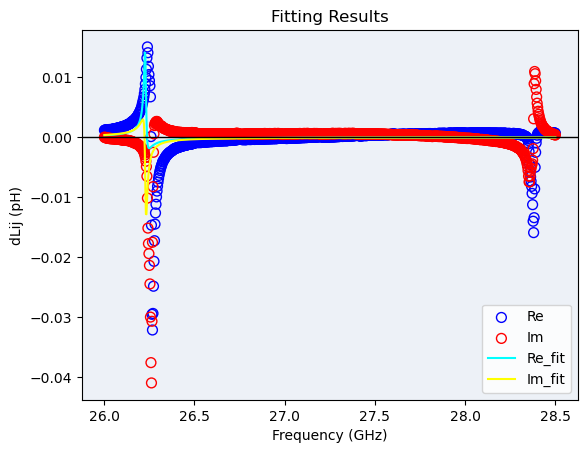

Final fit and results


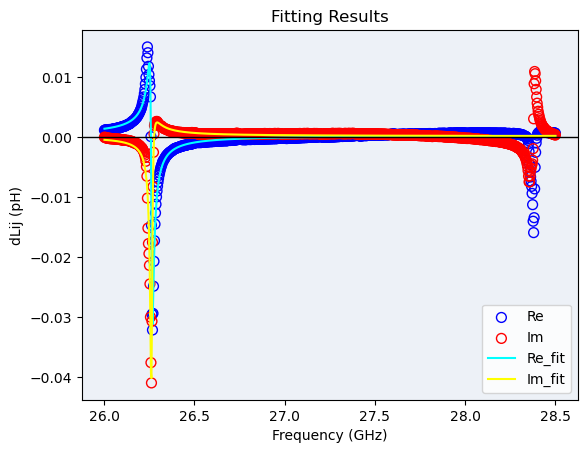


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.855e-04      4.708e-06         U        No
Ai                    -1.433e-04      4.708e-06         U        No
fo                       26.2634      1.508e-04       GHz        No
df                        0.0073      1.508e-04       GHz        No
re0                    3.441e-04      4.317e-05         U        No
im0                    1.513e-04      4.317e-05         U        No
----------------------------------------------------------------------
The phase is: 206.6546528421706


In [313]:
ini_vals = [1, 1, 27.2, 0.028, 0, 0] #A, w, fres, fper, fref, re0, im0
H_index = 8

f_min, f_max = 26, 28.5 #GHz
f_array = ansy1.freqs
y_array_re, y_array_im = ansy1.d_S("21R")[H_index], ansy1.d_S("21I")[H_index]

model = models.ComplexLorentzian_freq()
fitter = fits.ComplexFitter( ini_vals, f_min, f_max,
    f_array, y_array_re , y_array_im, model)
fitter.fix(fo=26.23, df=0.007, re0=0, im0=0) # Parameters to be fixed, empty otherwise
opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'
print(opt_p0)
print("Initial simplex fit")
fitter.plot_fit_simplex_wpm()

new_p0 = np.array(list(opt_p0.values()), dtype=float)
fitter.update_p0(new_p0)

params, cov = fitter.fit(simplex_b=False)
print("Final fit and results")
fitter.plot_fit()
fitter.summary()
print(f"The phase is: {model.phase_deg(**params)}")

In [234]:
#If we are happy with the fit, we can save it.

In [314]:
fit_dict = fitter.export_fit_dict()

fits_storage.save(index=H_index,field=float(ansy1.calc_field("inP")[H_index]),fit_dict=fit_dict)

In [236]:
# Automatic fitting of entire spectra. Enter the estimated parameters for the Kittel model guiding the automatic fitting.

Guide freq.=30.542198450127945
0


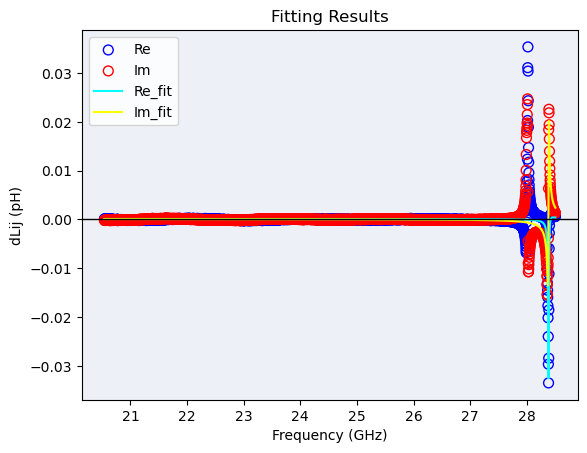


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     5.392e-05      5.892e-06         U        No
Ai                    -2.760e-04      5.892e-06         U        No
fo                       28.3790      2.426e-04       GHz        No
df                        0.0083      2.426e-04       GHz        No
re0                    1.087e-04      2.806e-05         U        No
im0                    1.102e-04      2.806e-05         U        No
----------------------------------------------------------------------
Guide freq.=30.269288877805742
1


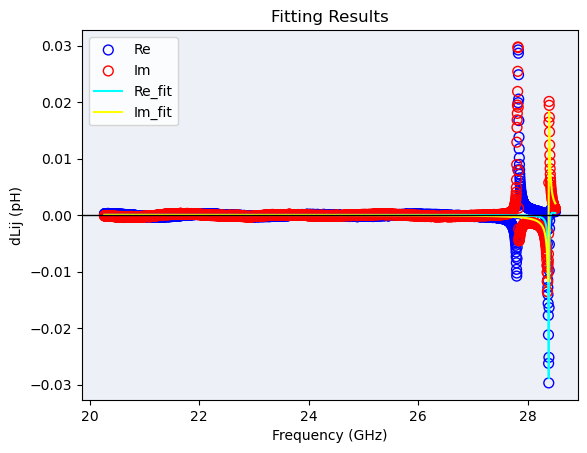


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     5.267e-05      5.530e-06         U        No
Ai                    -2.403e-04      5.530e-06         U        No
fo                       28.3792      2.559e-04       GHz        No
df                        0.0082      2.559e-04       GHz        No
re0                    9.146e-05      2.613e-05         U        No
im0                    8.390e-05      2.613e-05         U        No
----------------------------------------------------------------------
Guide freq.=29.977660641345068
2


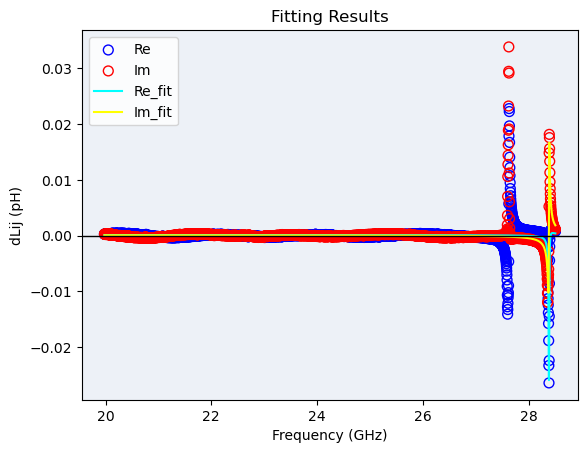


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     5.045e-05      5.256e-06         U        No
Ai                    -2.111e-04      5.256e-06         U        No
fo                       28.3793      2.716e-04       GHz        No
df                        0.0080      2.716e-04       GHz        No
re0                    8.774e-05      2.461e-05         U        No
im0                    7.449e-05      2.461e-05         U        No
----------------------------------------------------------------------
Guide freq.=29.677571444883146
3


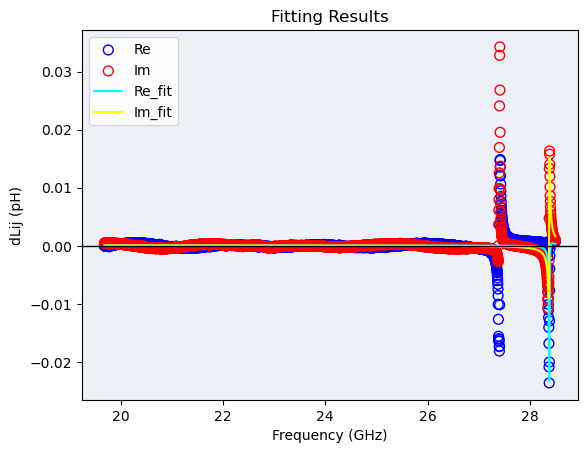


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.638e-05      5.110e-06         U        No
Ai                    -1.873e-04      5.110e-06         U        No
fo                       28.3794      2.941e-04       GHz        No
df                        0.0080      2.941e-04       GHz        No
re0                    7.697e-05      2.364e-05         U        No
im0                    8.176e-05      2.364e-05         U        No
----------------------------------------------------------------------
Guide freq.=29.380574950778765
4


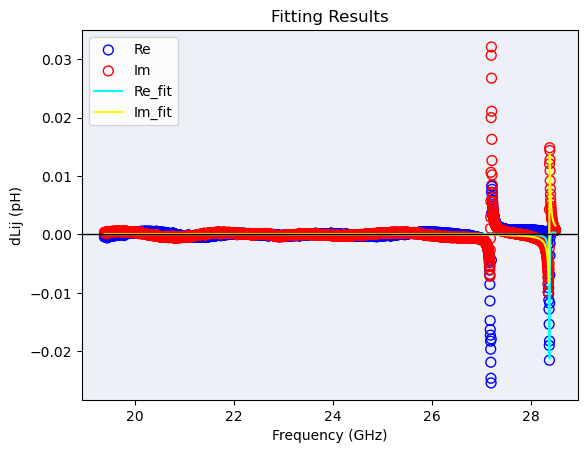


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.052e-05      4.990e-06         U        No
Ai                    -1.708e-04      4.990e-06         U        No
fo                       28.3793      3.148e-04       GHz        No
df                        0.0079      3.148e-04       GHz        No
re0                    6.304e-05      2.275e-05         U        No
im0                    8.588e-05      2.275e-05         U        No
----------------------------------------------------------------------
Guide freq.=29.086924991618655
5


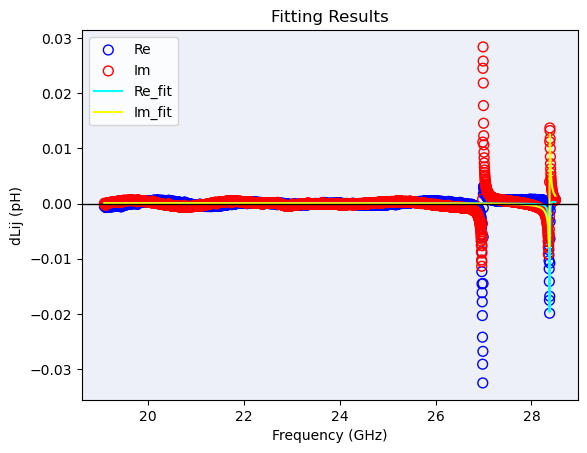


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.600e-05      5.037e-06         U        No
Ai                    -1.567e-04      5.037e-06         U        No
fo                       28.3793      3.434e-04       GHz        No
df                        0.0079      3.434e-04       GHz        No
re0                    4.489e-05      2.272e-05         U        No
im0                    8.702e-05      2.272e-05         U        No
----------------------------------------------------------------------
Guide freq.=28.743412089799826
6


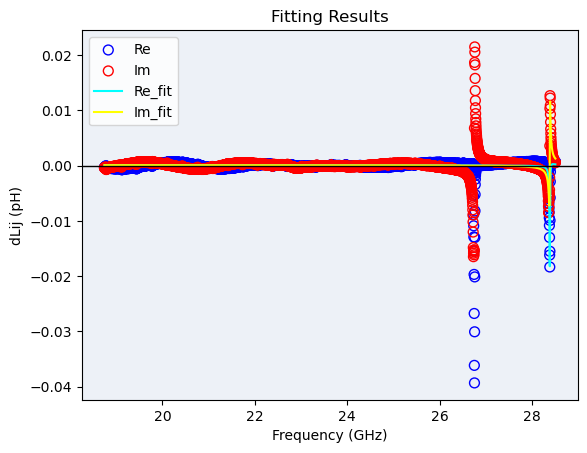


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.229e-05      5.298e-06         U        No
Ai                    -1.427e-04      5.298e-06         U        No
fo                       28.3793      3.908e-04       GHz        No
df                        0.0077      3.908e-04       GHz        No
re0                    2.486e-05      2.367e-05         U        No
im0                    7.480e-05      2.367e-05         U        No
----------------------------------------------------------------------
Guide freq.=28.41469756448741
7


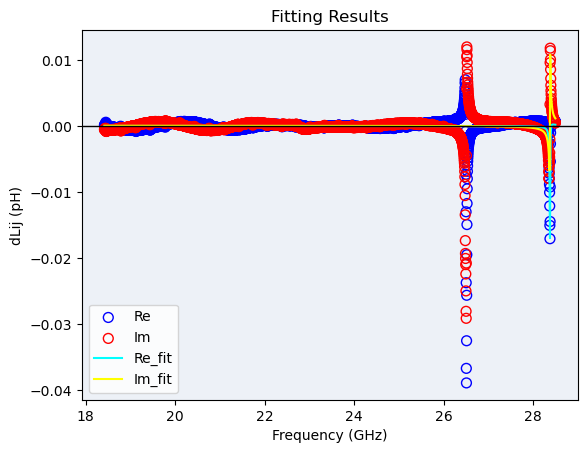


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.019e-05      5.518e-06         U        No
Ai                    -1.316e-04      5.518e-06         U        No
fo                       28.3793      4.377e-04       GHz        No
df                        0.0077      4.377e-04       GHz        No
re0                    1.152e-05      2.435e-05         U        No
im0                    5.023e-05      2.435e-05         U        No
----------------------------------------------------------------------
Guide freq.=28.0887038577728
8


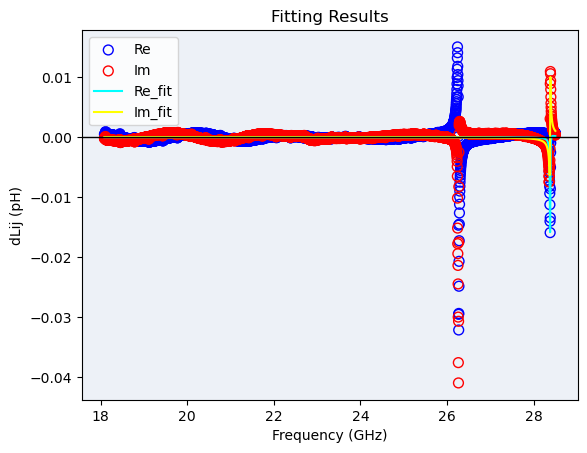


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.749e-05      5.683e-06         U        No
Ai                    -1.221e-04      5.683e-06         U        No
fo                       28.3793      4.829e-04       GHz        No
df                        0.0076      4.829e-04       GHz        No
re0                    2.320e-05      2.477e-05         U        No
im0                    3.317e-05      2.477e-05         U        No
----------------------------------------------------------------------
Guide freq.=27.706902318611846
9


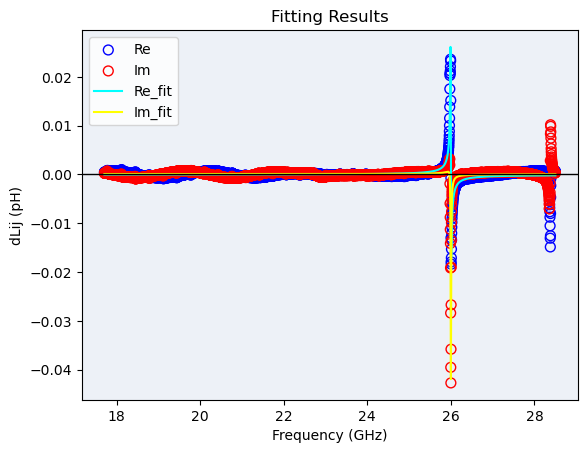


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.119e-04      2.499e-06         U        No
Ai                     6.796e-05      2.499e-06         U        No
fo                       25.9977      8.131e-05       GHz        No
df                        0.0074      8.131e-05       GHz        No
re0                   -6.071e-05      1.110e-05         U        No
im0                    7.105e-05      1.110e-05         U        No
----------------------------------------------------------------------
Guide freq.=27.357327621566732
10


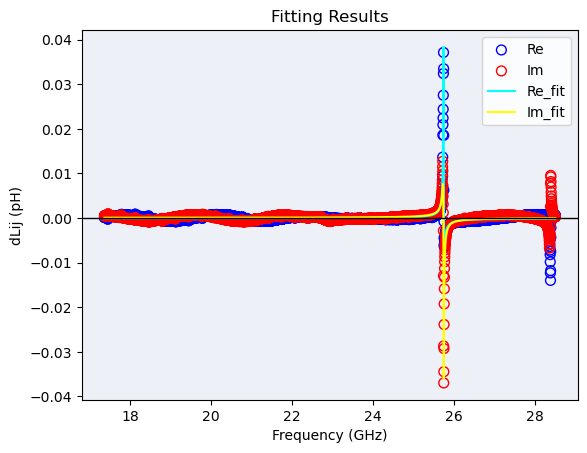


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.050e-04      2.396e-06         U        No
Ai                     2.379e-04      2.396e-06         U        No
fo                       25.7390      7.732e-05       GHz        No
df                        0.0072      7.732e-05       GHz        No
re0                   -8.223e-05      1.061e-05         U        No
im0                    3.463e-05      1.061e-05         U        No
----------------------------------------------------------------------
Guide freq.=26.949004169368212
11


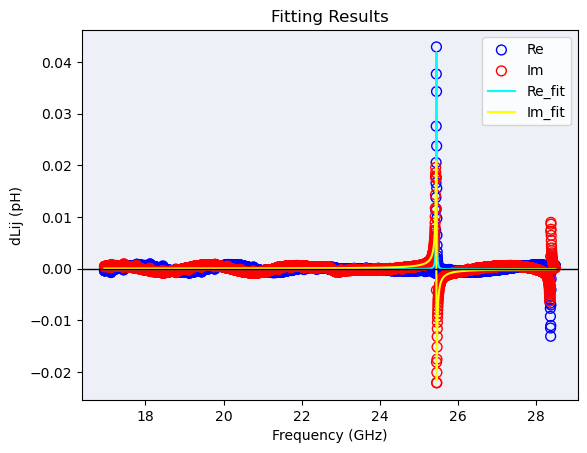


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -5.949e-06      2.258e-06         U        No
Ai                     2.991e-04      2.258e-06         U        No
fo                       25.4529      7.494e-05       GHz        No
df                        0.0070      7.494e-05       GHz        No
re0                   -8.199e-05      9.922e-06         U        No
im0                   -7.095e-06      9.922e-06         U        No
----------------------------------------------------------------------
Guide freq.=26.560193494666787
12


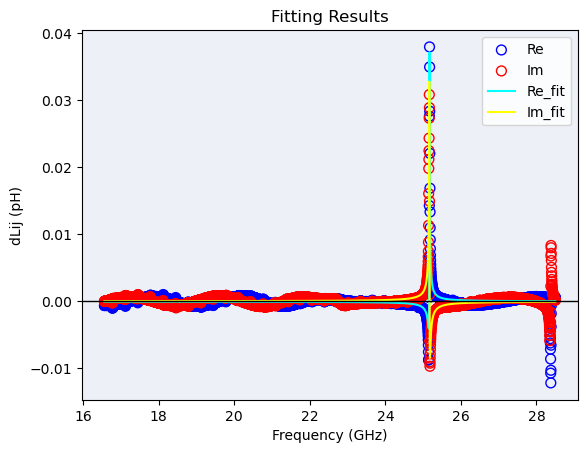


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.664e-04      2.139e-06         U        No
Ai                     2.273e-04      2.139e-06         U        No
fo                       25.1661      7.304e-05       GHz        No
df                        0.0068      7.304e-05       GHz        No
re0                   -6.452e-05      9.391e-06         U        No
im0                   -3.677e-05      9.391e-06         U        No
----------------------------------------------------------------------
Guide freq.=26.16071650361599
13


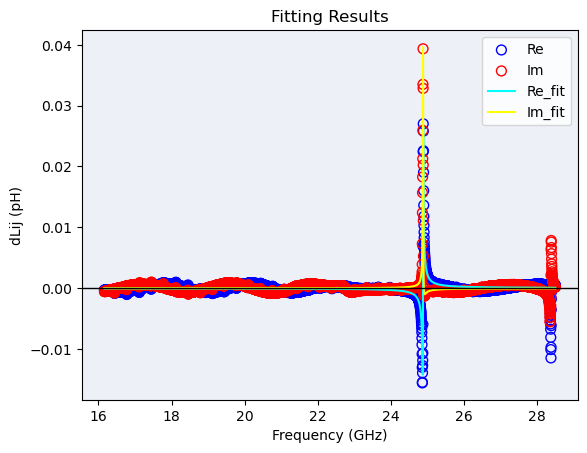


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.618e-04      2.042e-06         U        No
Ai                     8.330e-05      2.042e-06         U        No
fo                       24.8803      7.078e-05       GHz        No
df                        0.0067      7.078e-05       GHz        No
re0                   -3.224e-05      8.869e-06         U        No
im0                   -6.064e-05      8.869e-06         U        No
----------------------------------------------------------------------
Guide freq.=25.73432591758298
14


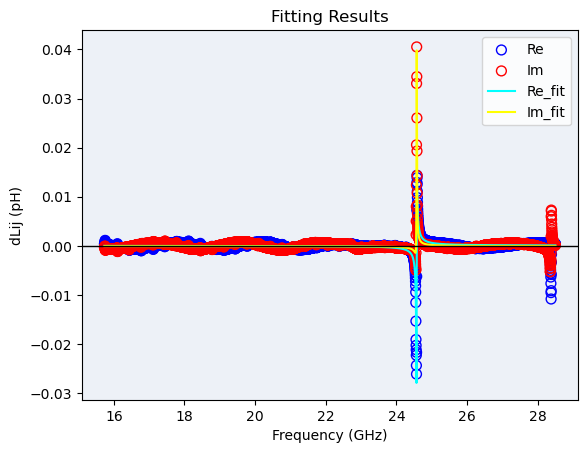


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.538e-04      1.956e-06         U        No
Ai                    -9.690e-05      1.956e-06         U        No
fo                       24.5729      6.685e-05       GHz        No
df                        0.0066      6.685e-05       GHz        No
re0                    1.047e-05      8.454e-06         U        No
im0                   -6.559e-05      8.454e-06         U        No
----------------------------------------------------------------------
Guide freq.=25.33396814896537
15


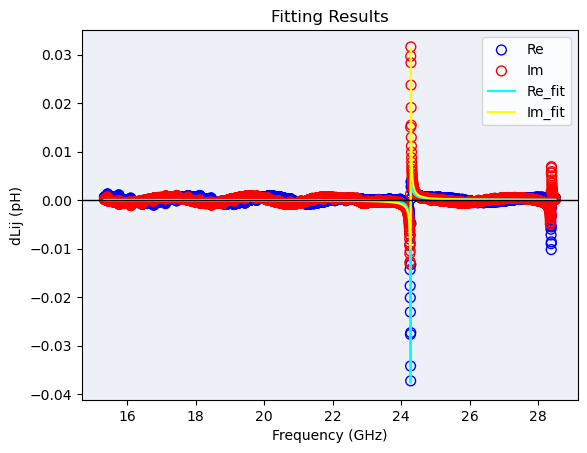


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.417e-04      1.874e-06         U        No
Ai                    -2.294e-04      1.874e-06         U        No
fo                       24.2758      6.372e-05       GHz        No
df                        0.0065      6.372e-05       GHz        No
re0                    5.098e-05      8.029e-06         U        No
im0                   -3.334e-05      8.029e-06         U        No
----------------------------------------------------------------------
Guide freq.=24.891525901998286
16


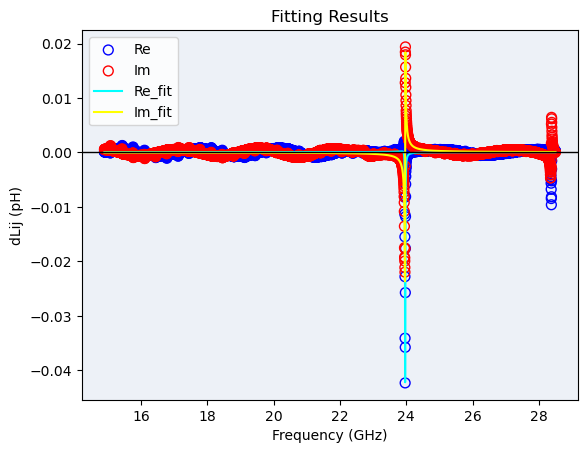


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.212e-05      1.806e-06         U        No
Ai                    -2.665e-04      1.806e-06         U        No
fo                       23.9664      6.018e-05       GHz        No
df                        0.0063      6.018e-05       GHz        No
re0                    6.124e-05      7.705e-06         U        No
im0                    2.093e-05      7.705e-06         U        No
----------------------------------------------------------------------
Guide freq.=24.46128340543512
17


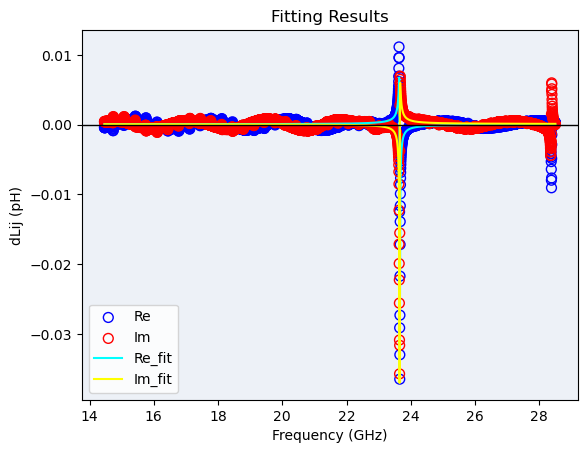


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.959e-04      1.763e-06         U        No
Ai                    -1.859e-04      1.763e-06         U        No
fo                       23.6533      5.778e-05       GHz        No
df                        0.0063      5.778e-05       GHz        No
re0                    2.675e-05      7.448e-06         U        No
im0                    6.720e-05      7.448e-06         U        No
----------------------------------------------------------------------
Guide freq.=24.009260203339146
18


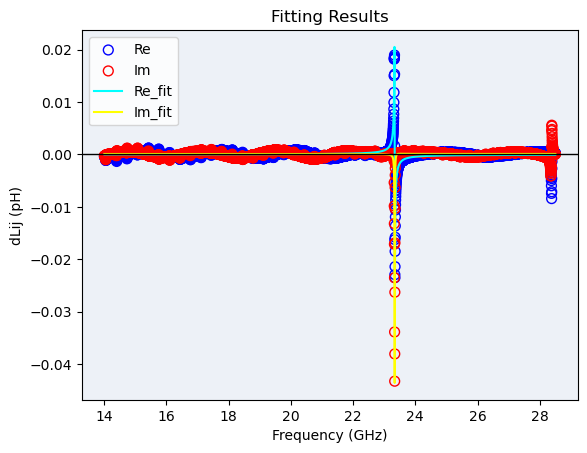


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.698e-04      1.690e-06         U        No
Ai                    -1.719e-05      1.690e-06         U        No
fo                       23.3374      5.433e-05       GHz        No
df                        0.0062      5.433e-05       GHz        No
re0                   -3.549e-05      7.087e-06         U        No
im0                    7.470e-05      7.087e-06         U        No
----------------------------------------------------------------------
Guide freq.=23.555296343029017
19


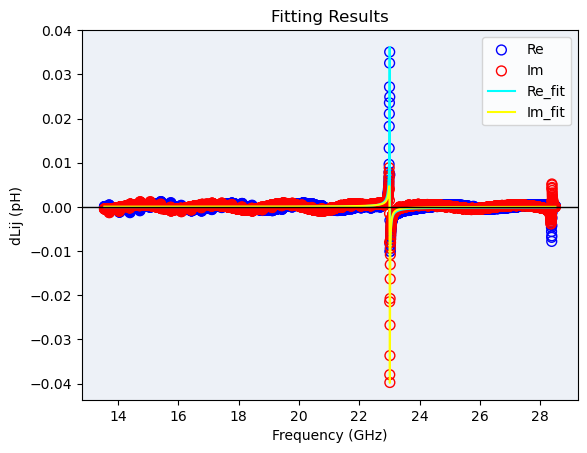


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.213e-04      1.639e-06         U        No
Ai                     1.686e-04      1.639e-06         U        No
fo                       23.0117      5.085e-05       GHz        No
df                        0.0061      5.085e-05       GHz        No
re0                   -7.413e-05      6.793e-06         U        No
im0                    4.003e-05      6.793e-06         U        No
----------------------------------------------------------------------
Guide freq.=23.13769019941462
20


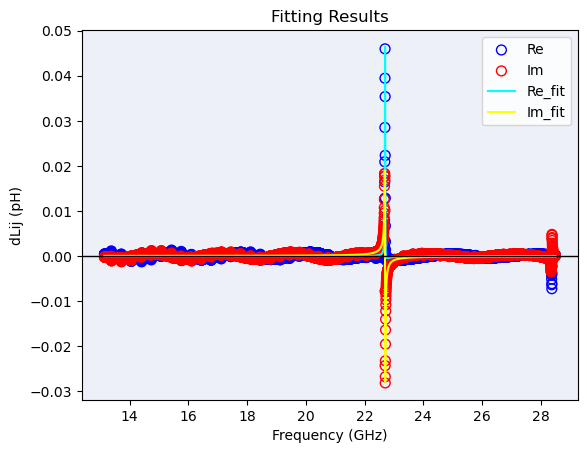


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -5.402e-05      1.596e-06         U        No
Ai                     2.834e-04      1.596e-06         U        No
fo                       22.6985      4.783e-05       GHz        No
df                        0.0061      4.783e-05       GHz        No
re0                   -8.023e-05      6.519e-06         U        No
im0                   -8.515e-06      6.519e-06         U        No
----------------------------------------------------------------------
Guide freq.=22.703705982905248
21


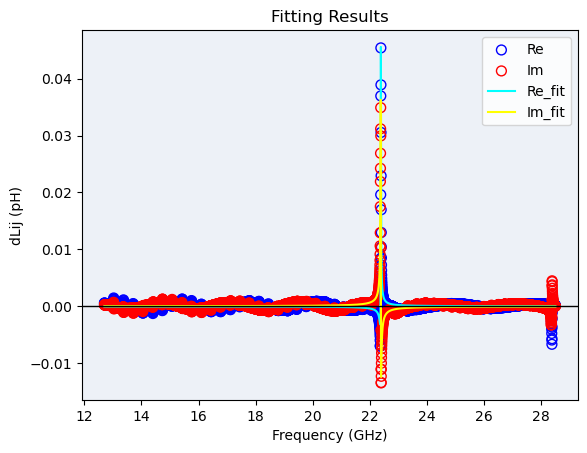


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.429e-04      1.553e-06         U        No
Ai                     2.534e-04      1.553e-06         U        No
fo                       22.3858      4.493e-05       GHz        No
df                        0.0060      4.493e-05       GHz        No
re0                   -5.637e-05      6.343e-06         U        No
im0                   -4.362e-05      6.343e-06         U        No
----------------------------------------------------------------------
Guide freq.=22.237541000864116
22


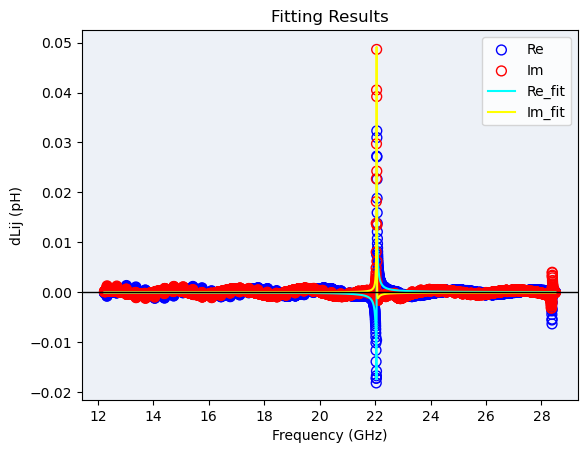


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.894e-04      1.514e-06         U        No
Ai                     9.108e-05      1.514e-06         U        No
fo                       22.0554      4.248e-05       GHz        No
df                        0.0060      4.248e-05       GHz        No
re0                   -1.658e-05      6.058e-06         U        No
im0                   -5.496e-05      6.058e-06         U        No
----------------------------------------------------------------------
Guide freq.=21.812584271553018
23


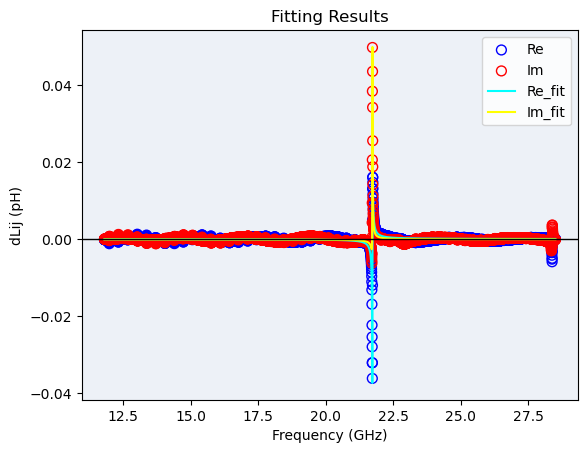


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.849e-04      1.466e-06         U        No
Ai                    -1.358e-04      1.466e-06         U        No
fo                       21.7312      3.943e-05       GHz        No
df                        0.0060      3.943e-05       GHz        No
re0                    2.254e-05      5.800e-06         U        No
im0                   -4.573e-05      5.800e-06         U        No
----------------------------------------------------------------------
Guide freq.=21.411474668719745
24


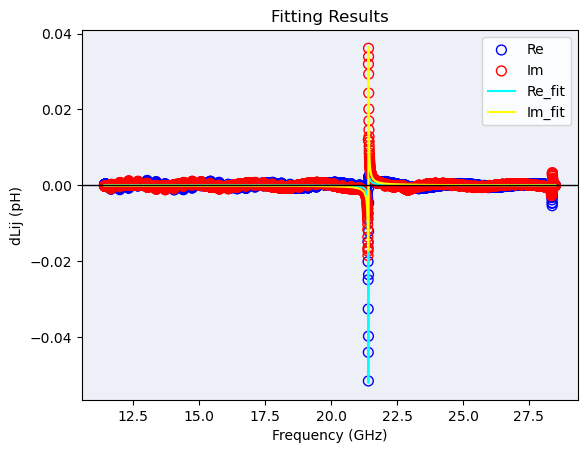


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.165e-04      1.397e-06         U        No
Ai                    -3.020e-04      1.397e-06         U        No
fo                       21.4142      3.661e-05       GHz        No
df                        0.0060      3.661e-05       GHz        No
re0                    4.893e-05      5.464e-06         U        No
im0                   -1.265e-05      5.464e-06         U        No
----------------------------------------------------------------------
Guide freq.=20.96660170233932
25


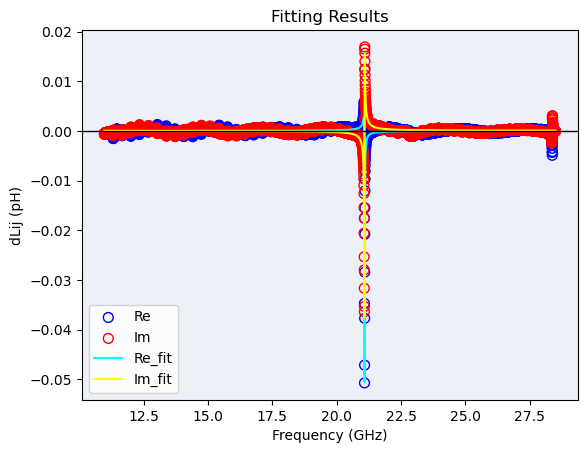


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.379e-04      1.336e-06         U        No
Ai                    -2.923e-04      1.336e-06         U        No
fo                       21.0795      3.477e-05       GHz        No
df                        0.0060      3.477e-05       GHz        No
re0                    2.424e-05      5.179e-06         U        No
im0                    2.584e-05      5.179e-06         U        No
----------------------------------------------------------------------
Guide freq.=20.564997401150475
26


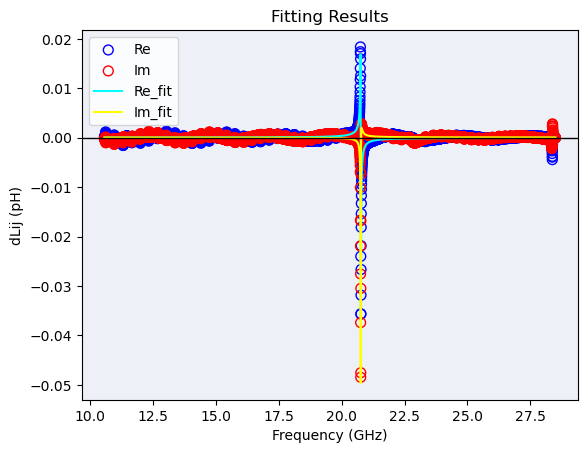


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.931e-04      1.285e-06         U        No
Ai                    -1.171e-04      1.285e-06         U        No
fo                       20.7604      3.377e-05       GHz        No
df                        0.0059      3.377e-05       GHz        No
re0                   -1.067e-05      4.963e-06         U        No
im0                    3.985e-05      4.963e-06         U        No
----------------------------------------------------------------------
Guide freq.=20.156641731213174
27


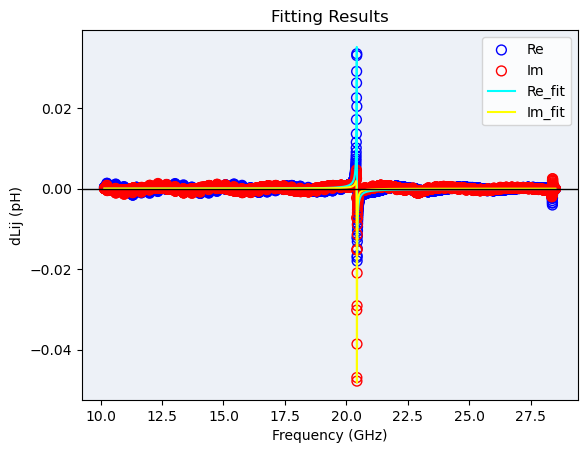


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.864e-04      1.257e-06         U        No
Ai                     1.146e-04      1.257e-06         U        No
fo                       20.4252      3.398e-05       GHz        No
df                        0.0059      3.398e-05       GHz        No
re0                   -4.322e-05      4.785e-06         U        No
im0                    2.773e-05      4.785e-06         U        No
----------------------------------------------------------------------
Guide freq.=19.758908556680733
28


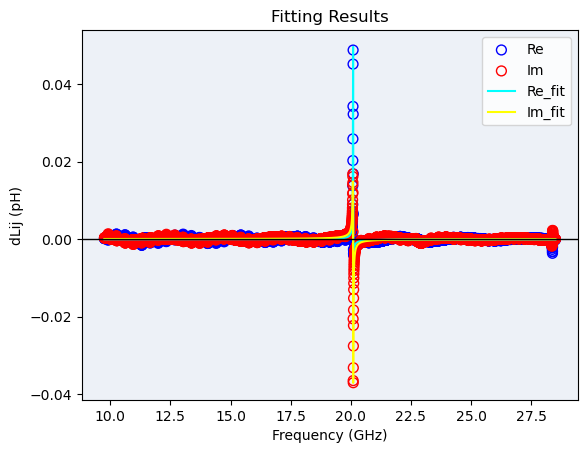


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.342e-04      1.183e-06         U        No
Ai                     2.705e-04      1.184e-06         U        No
fo                       20.0949      3.130e-05       GHz        No
df                        0.0057      3.130e-05       GHz        No
re0                   -5.850e-05      4.556e-06         U        No
im0                    5.664e-06      4.556e-06         U        No
----------------------------------------------------------------------
Guide freq.=19.40248683439432
29


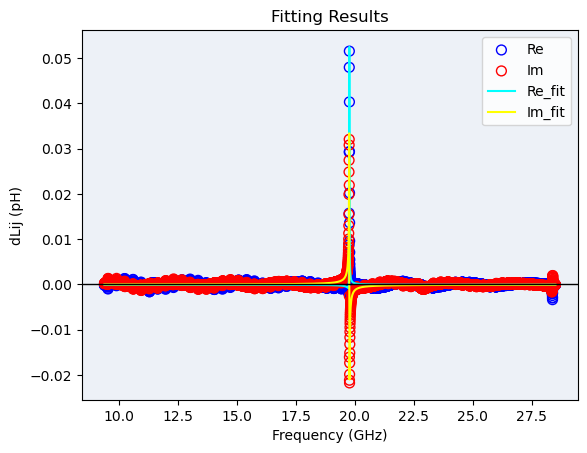


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     7.010e-05      1.161e-06         U        No
Ai                     2.965e-04      1.161e-06         U        No
fo                       19.7737      3.012e-05       GHz        No
df                        0.0056      3.012e-05       GHz        No
re0                   -5.731e-05      4.449e-06         U        No
im0                   -2.464e-05      4.449e-06         U        No
----------------------------------------------------------------------
Guide freq.=19.025220788500082
30


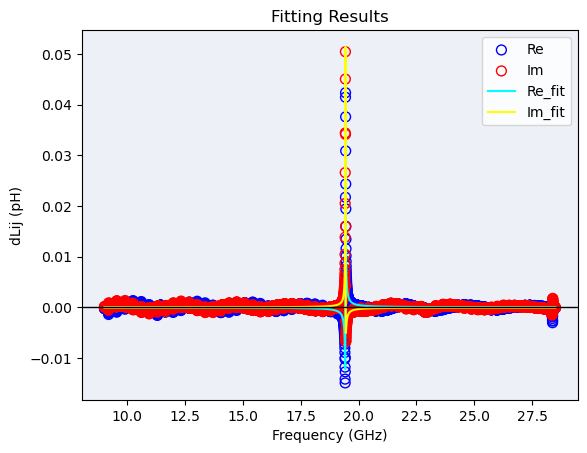


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.578e-04      1.144e-06         U        No
Ai                     1.782e-04      1.144e-06         U        No
fo                       19.4349      2.852e-05       GHz        No
df                        0.0055      2.852e-05       GHz        No
re0                   -3.901e-05      4.369e-06         U        No
im0                   -4.952e-05      4.369e-06         U        No
----------------------------------------------------------------------
Guide freq.=18.672564623406803
31


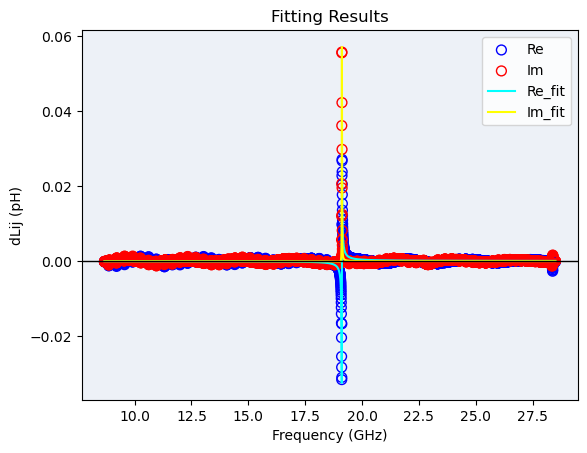


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.301e-04      1.128e-06         U        No
Ai                    -3.466e-05      1.128e-06         U        No
fo                       19.1129      2.664e-05       GHz        No
df                        0.0055      2.664e-05       GHz        No
re0                   -1.103e-05      4.260e-06         U        No
im0                   -5.730e-05      4.260e-06         U        No
----------------------------------------------------------------------
Guide freq.=18.328573693255734
32


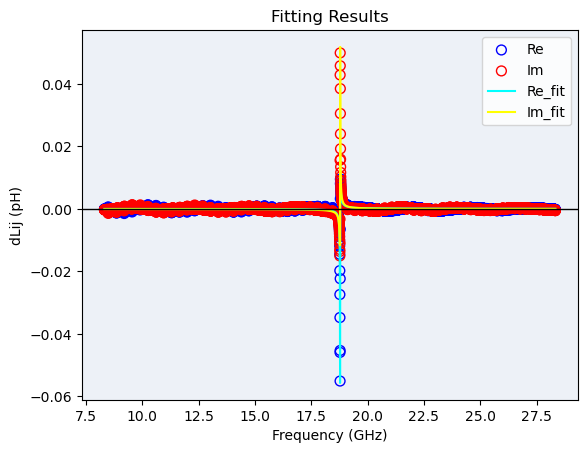


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.237e-04      1.100e-06         U        No
Ai                    -2.719e-04      1.100e-06         U        No
fo                       18.7811      2.442e-05       GHz        No
df                        0.0055      2.442e-05       GHz        No
re0                    3.374e-05      4.146e-06         U        No
im0                   -4.094e-05      4.146e-06         U        No
----------------------------------------------------------------------
Guide freq.=17.978538906522473
33


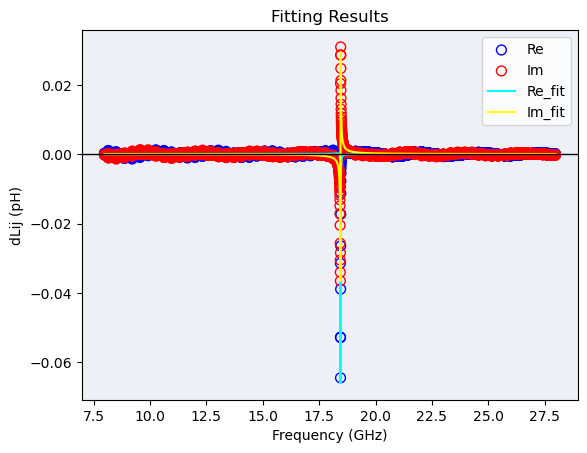


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.948e-05      1.104e-06         U        No
Ai                    -3.676e-04      1.104e-06         U        No
fo                       18.4478      2.358e-05       GHz        No
df                        0.0056      2.358e-05       GHz        No
re0                    5.617e-05      4.139e-06         U        No
im0                    6.689e-06      4.139e-06         U        No
----------------------------------------------------------------------
Guide freq.=17.649399982031504
34


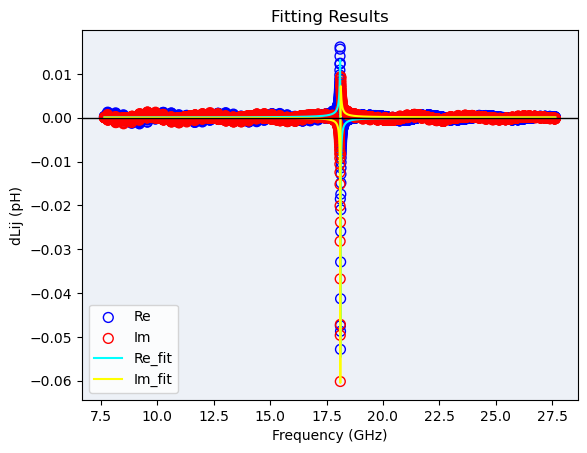


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.984e-04      1.105e-06         U        No
Ai                    -2.317e-04      1.105e-06         U        No
fo                       18.1144      2.289e-05       GHz        No
df                        0.0055      2.289e-05       GHz        No
re0                    3.852e-05      4.157e-06         U        No
im0                    4.680e-05      4.157e-06         U        No
----------------------------------------------------------------------
Guide freq.=17.31246560083849
35


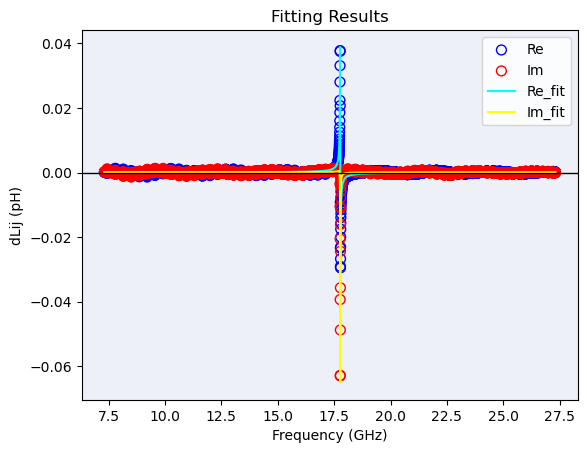


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.722e-04      1.110e-06         U        No
Ai                     5.793e-05      1.110e-06         U        No
fo                       17.7717      2.305e-05       GHz        No
df                        0.0055      2.305e-05       GHz        No
re0                   -5.735e-06      4.180e-06         U        No
im0                    6.152e-05      4.180e-06         U        No
----------------------------------------------------------------------
Guide freq.=16.99340865065687
36


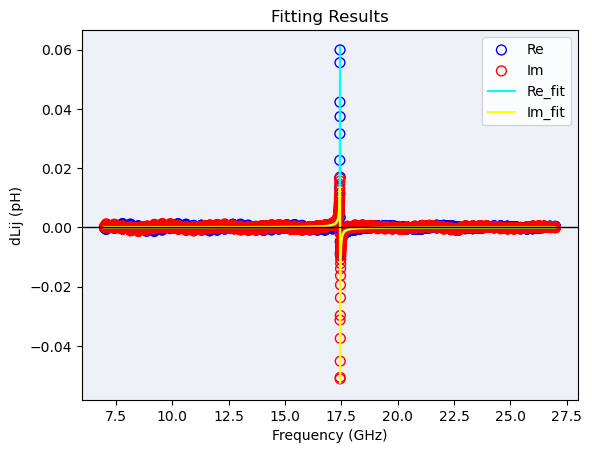


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.256e-04      1.098e-06         U        No
Ai                     3.001e-04      1.098e-06         U        No
fo                       17.4440      2.264e-05       GHz        No
df                        0.0055      2.264e-05       GHz        No
re0                   -3.563e-05      4.159e-06         U        No
im0                    4.009e-05      4.159e-06         U        No
----------------------------------------------------------------------
Guide freq.=16.690495764323252
37


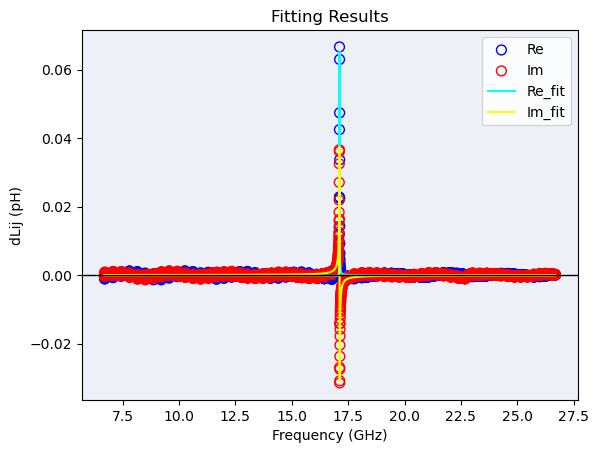


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.611e-05      1.115e-06         U        No
Ai                     3.751e-04      1.115e-06         U        No
fo                       17.1164      2.271e-05       GHz        No
df                        0.0054      2.271e-05       GHz        No
re0                   -4.340e-05      4.239e-06         U        No
im0                   -1.533e-06      4.239e-06         U        No
----------------------------------------------------------------------
Guide freq.=16.36309340135874
38


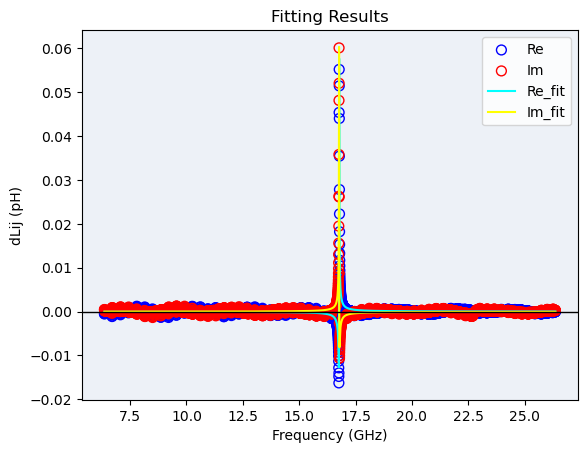


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.948e-04      1.112e-06         U        No
Ai                     2.457e-04      1.112e-06         U        No
fo                       16.7710      2.234e-05       GHz        No
df                        0.0055      2.234e-05       GHz        No
re0                   -2.080e-05      4.219e-06         U        No
im0                   -4.091e-05      4.219e-06         U        No
----------------------------------------------------------------------
Guide freq.=16.036297301736614
39


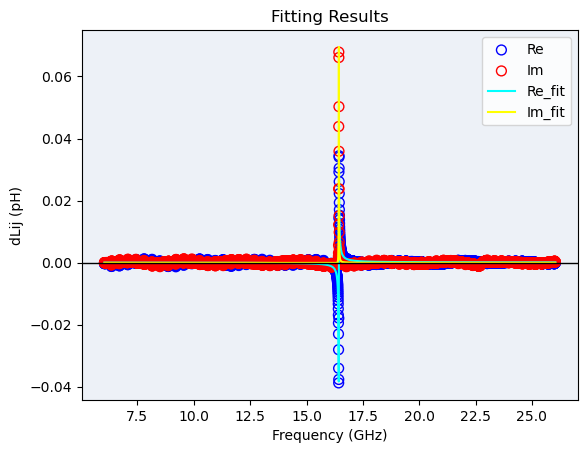


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.999e-04      1.140e-06         U        No
Ai                    -2.852e-05      1.140e-06         U        No
fo                       16.4334      2.214e-05       GHz        No
df                        0.0055      2.214e-05       GHz        No
re0                    2.352e-05      4.303e-06         U        No
im0                   -5.786e-05      4.303e-06         U        No
----------------------------------------------------------------------
Guide freq.=15.721990374077434
40


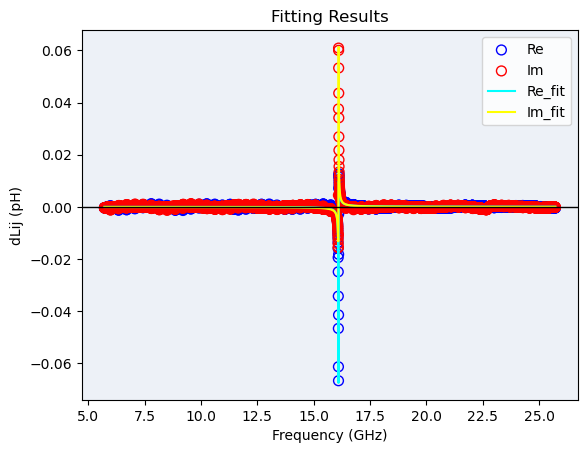


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.831e-04      1.157e-06         U        No
Ai                    -3.211e-04      1.157e-06         U        No
fo                       16.1032      2.105e-05       GHz        No
df                        0.0055      2.105e-05       GHz        No
re0                    6.850e-05      4.369e-06         U        No
im0                   -3.913e-05      4.369e-06         U        No
----------------------------------------------------------------------
Guide freq.=15.39293680731186
41


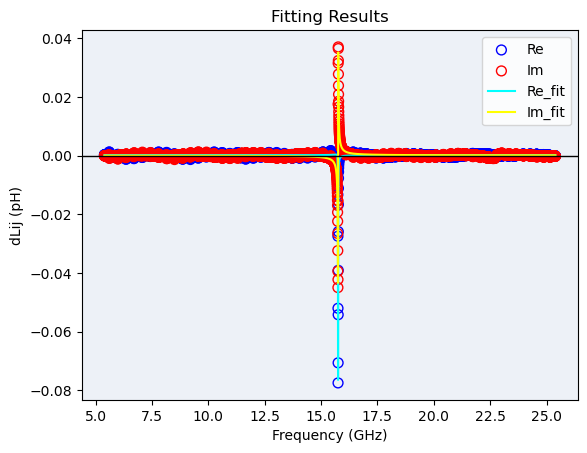


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.935e-05      1.209e-06         U        No
Ai                    -4.409e-04      1.209e-06         U        No
fo                       15.7553      2.117e-05       GHz        No
df                        0.0055      2.117e-05       GHz        No
re0                    9.505e-05      4.568e-06         U        No
im0                    1.691e-05      4.568e-06         U        No
----------------------------------------------------------------------
Guide freq.=15.074654718882892
42


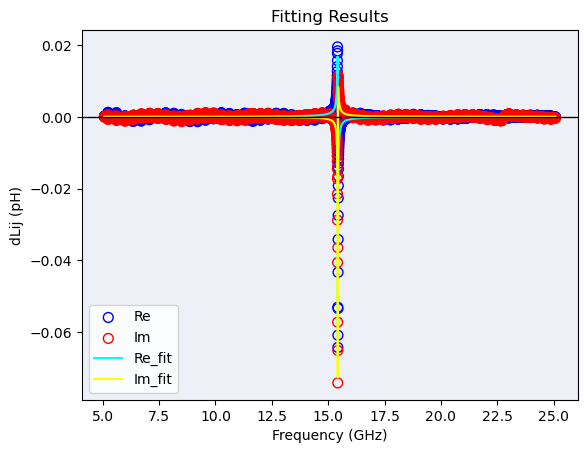


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.697e-04      1.237e-06         U        No
Ai                    -2.768e-04      1.237e-06         U        No
fo                       15.4243      2.078e-05       GHz        No
df                        0.0055      2.078e-05       GHz        No
re0                    6.731e-05      4.675e-06         U        No
im0                    6.615e-05      4.675e-06         U        No
----------------------------------------------------------------------
Guide freq.=14.739989485397592
43


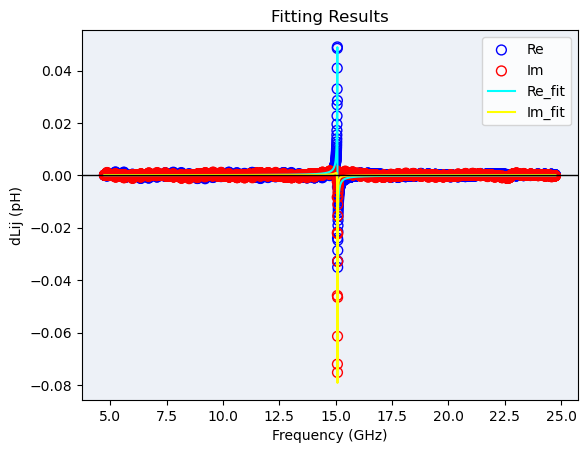


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.540e-04      1.259e-06         U        No
Ai                     9.412e-05      1.259e-06         U        No
fo                       15.0755      2.182e-05       GHz        No
df                        0.0057      2.182e-05       GHz        No
re0                    9.890e-06      4.679e-06         U        No
im0                    8.242e-05      4.679e-06         U        No
----------------------------------------------------------------------
Guide freq.=14.41534211443098
44


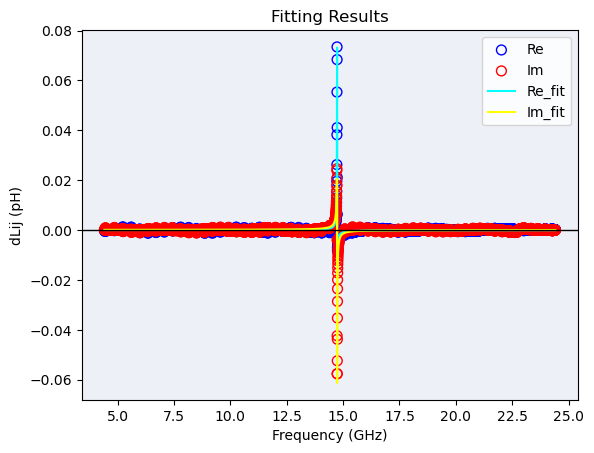


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.274e-04      1.238e-06         U        No
Ai                     3.928e-04      1.238e-06         U        No
fo                       14.7354      2.119e-05       GHz        No
df                        0.0055      2.119e-05       GHz        No
re0                   -3.598e-05      4.678e-06         U        No
im0                    4.711e-05      4.678e-06         U        No
----------------------------------------------------------------------
Guide freq.=14.08725553184643
45


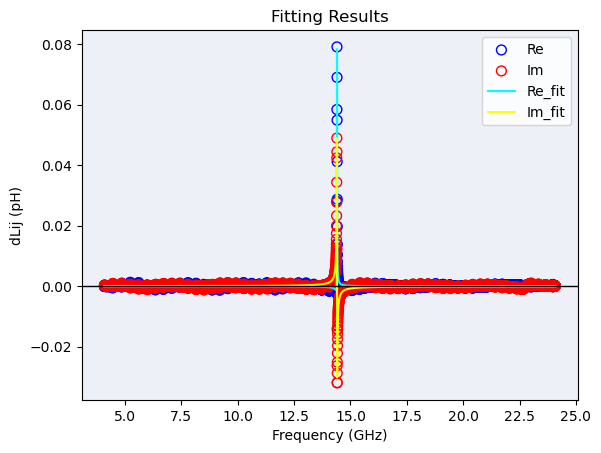


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.095e-04      1.249e-06         U        No
Ai                     4.357e-04      1.249e-06         U        No
fo                       14.4020      2.182e-05       GHz        No
df                        0.0056      2.182e-05       GHz        No
re0                   -4.155e-05      4.696e-06         U        No
im0                   -7.898e-06      4.696e-06         U        No
----------------------------------------------------------------------
Guide freq.=13.741931867548278
46


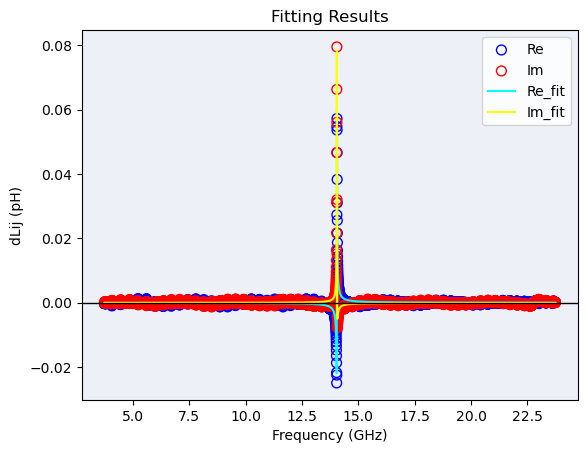


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.997e-04      1.238e-06         U        No
Ai                     2.146e-04      1.238e-06         U        No
fo                       14.0506      2.100e-05       GHz        No
df                        0.0054      2.100e-05       GHz        No
re0                   -6.524e-06      4.700e-06         U        No
im0                   -4.571e-05      4.700e-06         U        No
----------------------------------------------------------------------
Guide freq.=13.40729603772181
47


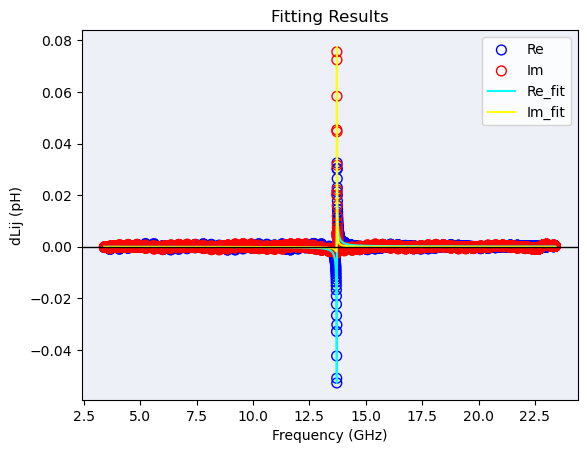


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.296e-04      1.234e-06         U        No
Ai                    -1.287e-04      1.234e-06         U        No
fo                       13.7169      2.118e-05       GHz        No
df                        0.0054      2.118e-05       GHz        No
re0                    4.318e-05      4.683e-06         U        No
im0                   -5.153e-05      4.683e-06         U        No
----------------------------------------------------------------------
Guide freq.=13.070075848941048
48


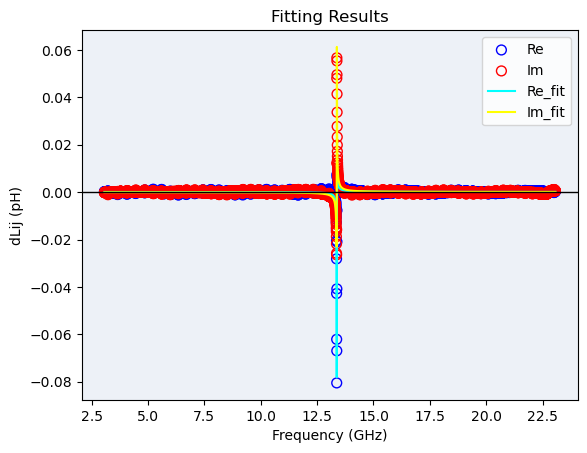


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.091e-04      1.260e-06         U        No
Ai                    -4.157e-04      1.260e-06         U        No
fo                       13.3738      2.107e-05       GHz        No
df                        0.0055      2.107e-05       GHz        No
re0                    7.957e-05      4.759e-06         U        No
im0                   -2.213e-05      4.759e-06         U        No
----------------------------------------------------------------------
Guide freq.=12.716725471536048
49


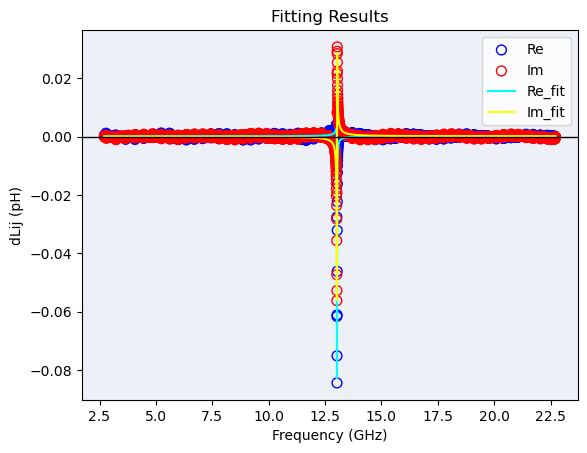


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.615e-04      1.308e-06         U        No
Ai                    -4.477e-04      1.308e-06         U        No
fo                       13.0298      2.121e-05       GHz        No
df                        0.0055      2.121e-05       GHz        No
re0                    7.954e-05      4.960e-06         U        No
im0                    2.740e-05      4.960e-06         U        No
----------------------------------------------------------------------
Guide freq.=12.376265465339623
50


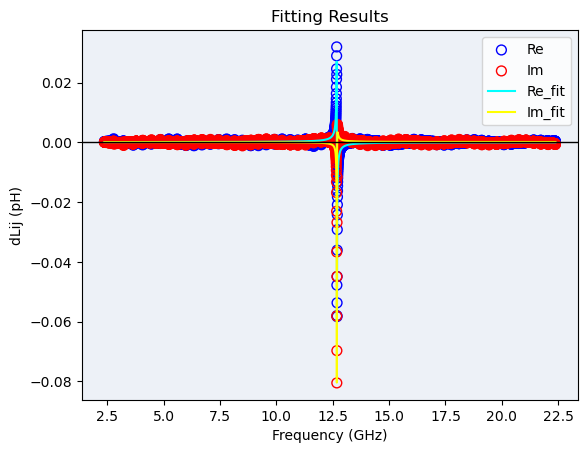


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.336e-04      1.311e-06         U        No
Ai                    -1.791e-04      1.311e-06         U        No
fo                       12.6851      2.121e-05       GHz        No
df                        0.0054      2.121e-05       GHz        No
re0                    3.447e-05      5.012e-06         U        No
im0                    7.949e-05      5.012e-06         U        No
----------------------------------------------------------------------
Guide freq.=12.021183095675978
51


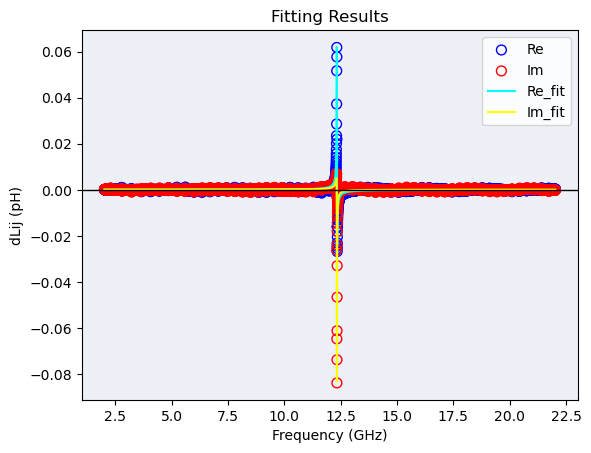


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.240e-04      1.290e-06         U        No
Ai                     2.196e-04      1.290e-06         U        No
fo                       12.3320      2.049e-05       GHz        No
df                        0.0054      2.049e-05       GHz        No
re0                   -2.940e-05      4.934e-06         U        No
im0                    7.653e-05      4.934e-06         U        No
----------------------------------------------------------------------
Guide freq.=11.68070329703296
52


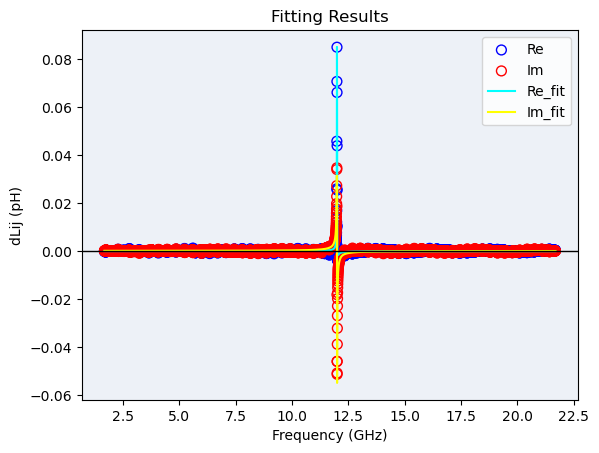


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.288e-04      1.257e-06         U        No
Ai                     4.510e-04      1.257e-06         U        No
fo                       11.9950      2.042e-05       GHz        No
df                        0.0054      2.042e-05       GHz        No
re0                   -6.404e-05      4.795e-06         U        No
im0                    3.210e-05      4.795e-06         U        No
----------------------------------------------------------------------
Guide freq.=11.355471611130822
53


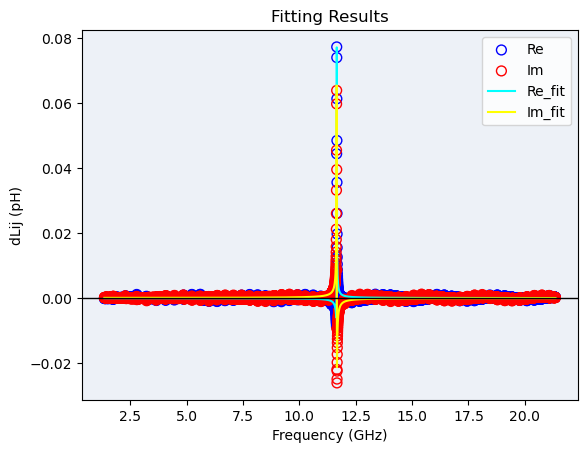


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.293e-04      1.205e-06         U        No
Ai                     3.907e-04      1.205e-06         U        No
fo                       11.6581      1.961e-05       GHz        No
df                        0.0052      1.961e-05       GHz        No
re0                   -5.355e-05      4.672e-06         U        No
im0                   -2.408e-05      4.672e-06         U        No
----------------------------------------------------------------------
Guide freq.=10.989777225692627
54


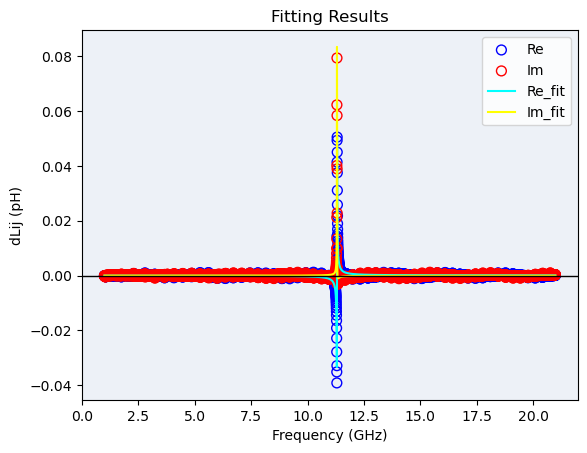


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.111e-04      1.188e-06         U        No
Ai                     8.847e-05      1.188e-06         U        No
fo                       11.3032      1.985e-05       GHz        No
df                        0.0050      1.985e-05       GHz        No
re0                   -1.247e-05      4.724e-06         U        No
im0                   -4.923e-05      4.724e-06         U        No
----------------------------------------------------------------------
Guide freq.=10.65455452050003
55


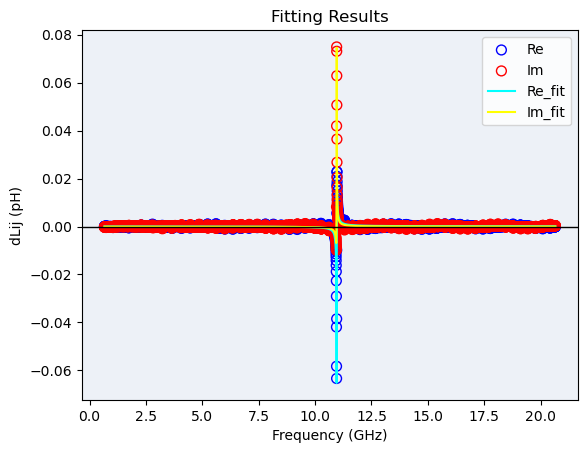


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.679e-04      1.243e-06         U        No
Ai                    -2.392e-04      1.243e-06         U        No
fo                       10.9553      2.079e-05       GHz        No
df                        0.0052      2.079e-05       GHz        No
re0                    3.951e-05      4.830e-06         U        No
im0                   -4.167e-05      4.830e-06         U        No
----------------------------------------------------------------------
Guide freq.=10.321847712345974
56


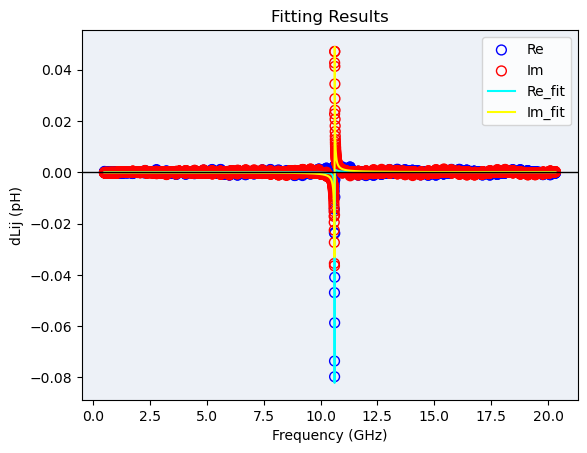


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     8.756e-05      1.226e-06         U        No
Ai                    -4.276e-04      1.226e-06         U        No
fo                       10.6166      2.077e-05       GHz        No
df                        0.0052      2.077e-05       GHz        No
re0                    6.308e-05      4.771e-06         U        No
im0                   -3.367e-06      4.771e-06         U        No
----------------------------------------------------------------------
Guide freq.=9.977961987320542
57


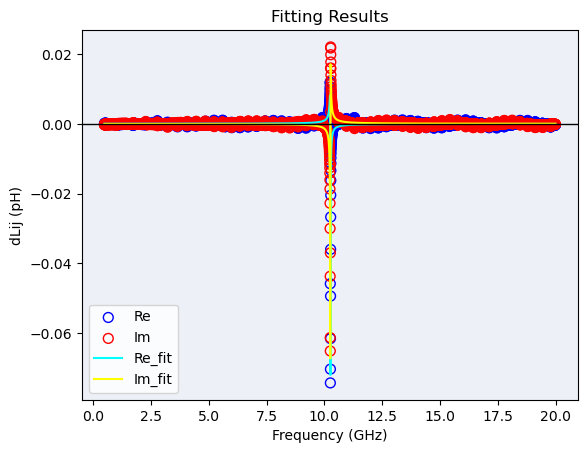


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.581e-04      1.293e-06         U        No
Ai                    -3.522e-04      1.293e-06         U        No
fo                       10.2577      2.159e-05       GHz        No
df                        0.0052      2.159e-05       GHz        No
re0                    5.417e-05      5.113e-06         U        No
im0                    5.044e-05      5.113e-06         U        No
----------------------------------------------------------------------
Guide freq.=9.663752812790028
58


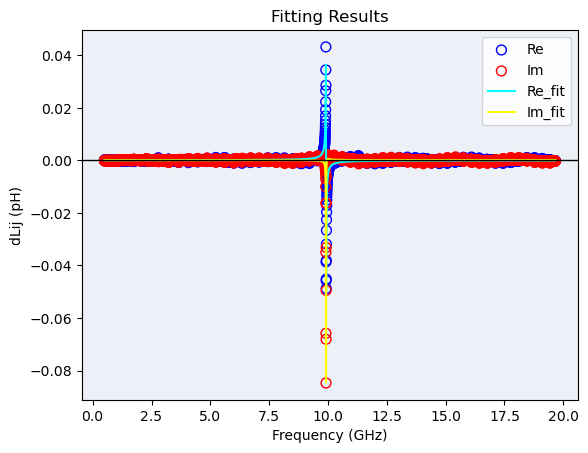


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.380e-04      1.341e-06         U        No
Ai                    -6.621e-05      1.341e-06         U        No
fo                        9.9174      2.201e-05       GHz        No
df                        0.0051      2.201e-05       GHz        No
re0                    8.256e-06      5.349e-06         U        No
im0                    7.572e-05      5.349e-06         U        No
----------------------------------------------------------------------
Guide freq.=9.310429975483022
59


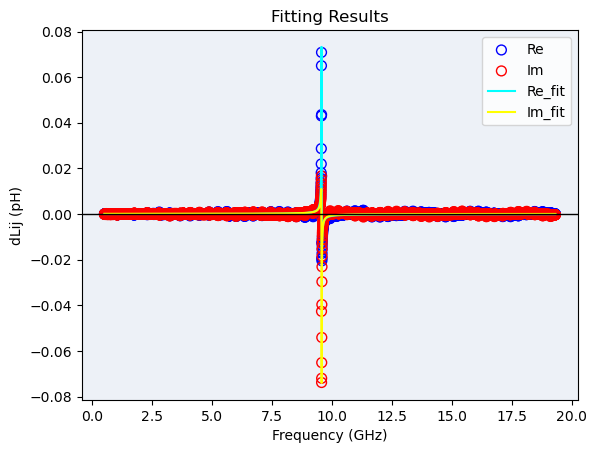


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.394e-04      1.376e-06         U        No
Ai                     2.967e-04      1.376e-06         U        No
fo                        9.5576      2.199e-05       GHz        No
df                        0.0051      2.199e-05       GHz        No
re0                   -4.623e-05      5.567e-06         U        No
im0                    6.054e-05      5.567e-06         U        No
----------------------------------------------------------------------
Guide freq.=8.985163908184058
60


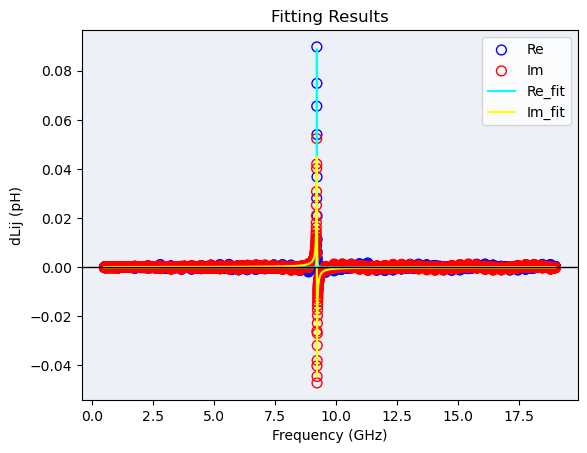


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.000e-05      1.333e-06         U        No
Ai                     4.516e-04      1.333e-06         U        No
fo                        9.2060      2.061e-05       GHz        No
df                        0.0049      2.061e-05       GHz        No
re0                   -7.035e-05      5.527e-06         U        No
im0                    7.786e-06      5.527e-06         U        No
----------------------------------------------------------------------
Guide freq.=8.65961997639693
61


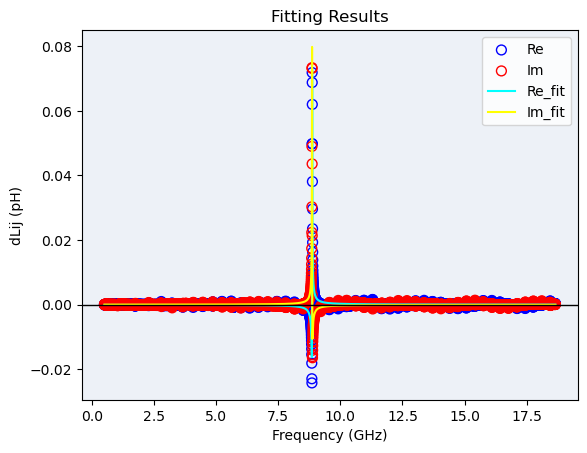


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.462e-04      1.396e-06         U        No
Ai                     2.900e-04      1.396e-06         U        No
fo                        8.8621      2.164e-05       GHz        No
df                        0.0050      2.164e-05       GHz        No
re0                   -4.458e-05      5.831e-06         U        No
im0                   -4.860e-05      5.831e-06         U        No
----------------------------------------------------------------------
Guide freq.=8.31881300508282
62


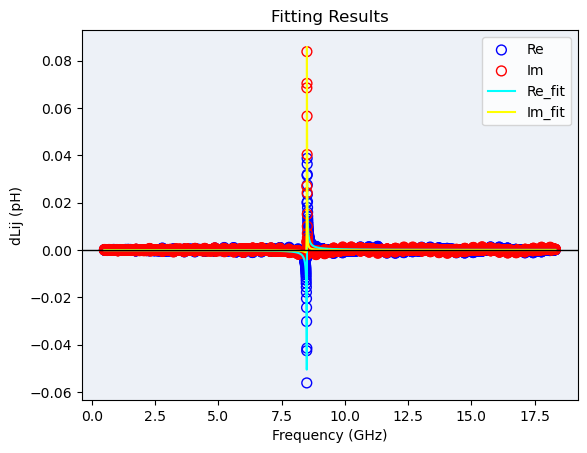


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.226e-04      1.397e-06         U        No
Ai                    -8.735e-05      1.397e-06         U        No
fo                        8.4994      2.267e-05       GHz        No
df                        0.0050      2.267e-05       GHz        No
re0                    1.900e-05      5.889e-06         U        No
im0                   -6.085e-05      5.889e-06         U        No
----------------------------------------------------------------------
Guide freq.=7.988518016179278
63


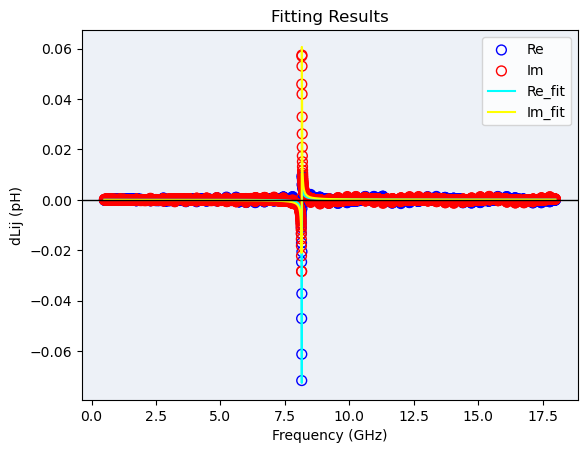


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.893e-04      1.327e-06         U        No
Ai                    -3.412e-04      1.327e-06         U        No
fo                        8.1526      2.293e-05       GHz        No
df                        0.0048      2.293e-05       GHz        No
re0                    6.420e-05      5.755e-06         U        No
im0                   -2.424e-05      5.755e-06         U        No
----------------------------------------------------------------------
Guide freq.=7.653656915615389
64


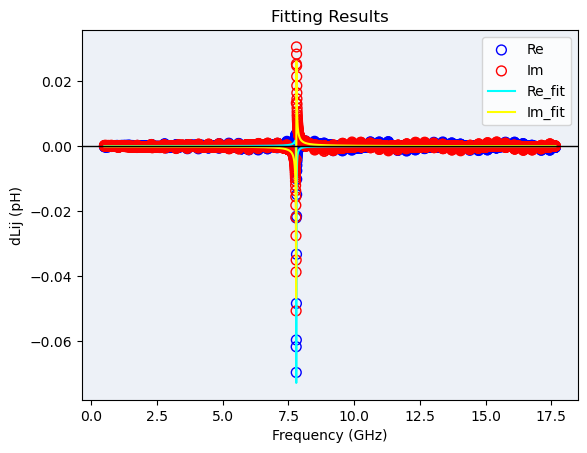


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.090e-04      1.282e-06         U        No
Ai                    -3.504e-04      1.282e-06         U        No
fo                        7.7961      2.425e-05       GHz        No
df                        0.0049      2.425e-05       GHz        No
re0                    6.954e-05      5.533e-06         U        No
im0                    2.633e-05      5.533e-06         U        No
----------------------------------------------------------------------
Guide freq.=7.298443571068554
65


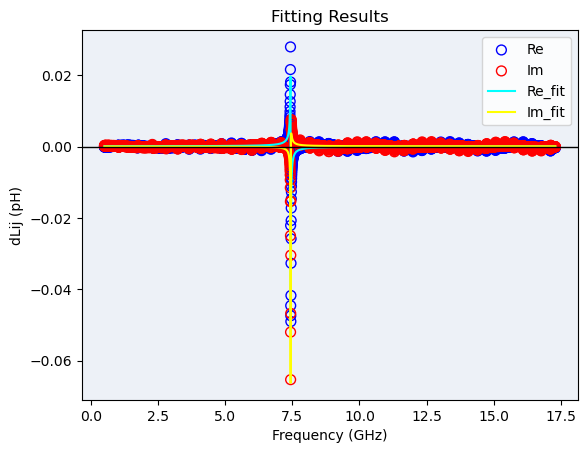


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.081e-04      1.286e-06         U        No
Ai                    -1.518e-04      1.286e-06         U        No
fo                        7.4373      2.570e-05       GHz        No
df                        0.0049      2.570e-05       GHz        No
re0                    3.631e-05      5.640e-06         U        No
im0                    5.862e-05      5.640e-06         U        No
----------------------------------------------------------------------
Guide freq.=6.949991907761259
66


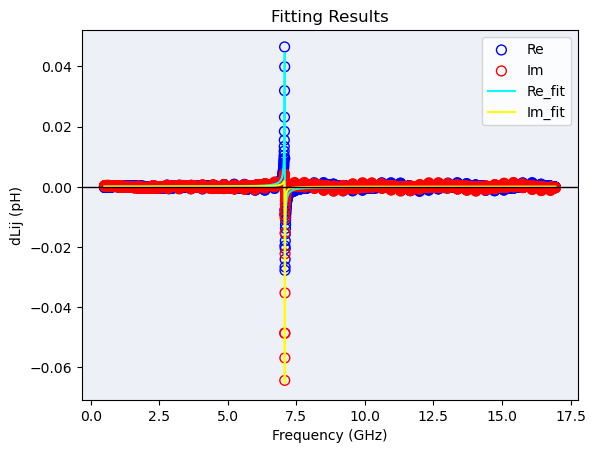


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.178e-04      1.310e-06         U        No
Ai                     1.074e-04      1.310e-06         U        No
fo                        7.0771      2.697e-05       GHz        No
df                        0.0049      2.697e-05       GHz        No
re0                   -7.832e-06      5.788e-06         U        No
im0                    6.473e-05      5.788e-06         U        No
----------------------------------------------------------------------
Guide freq.=6.578213592648964
67


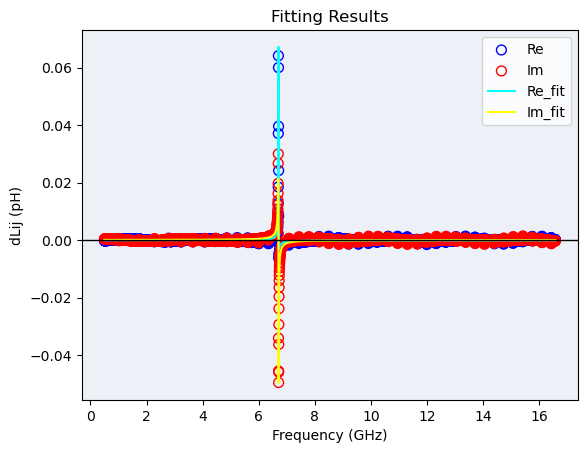


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.382e-04      1.316e-06         U        No
Ai                     3.177e-04      1.316e-06         U        No
fo                        6.7050      2.584e-05       GHz        No
df                        0.0048      2.584e-05       GHz        No
re0                   -4.618e-05      5.922e-06         U        No
im0                    3.727e-05      5.922e-06         U        No
----------------------------------------------------------------------
Guide freq.=6.212283786438648
68


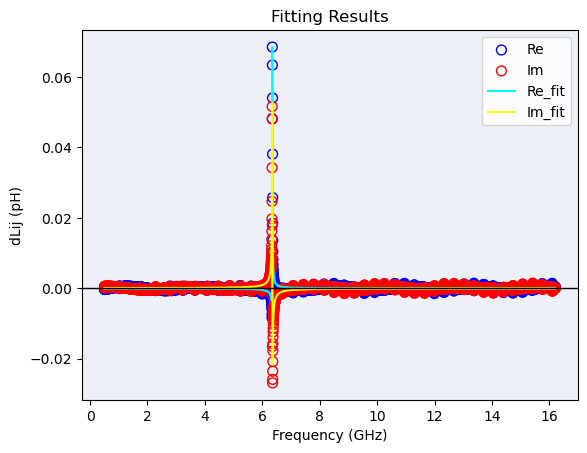


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.500e-04      1.405e-06         U        No
Ai                     3.281e-04      1.405e-06         U        No
fo                        6.3491      2.656e-05       GHz        No
df                        0.0048      2.656e-05       GHz        No
re0                   -5.564e-05      6.389e-06         U        No
im0                   -1.863e-05      6.389e-06         U        No
----------------------------------------------------------------------
Guide freq.=5.8374696052889306
69


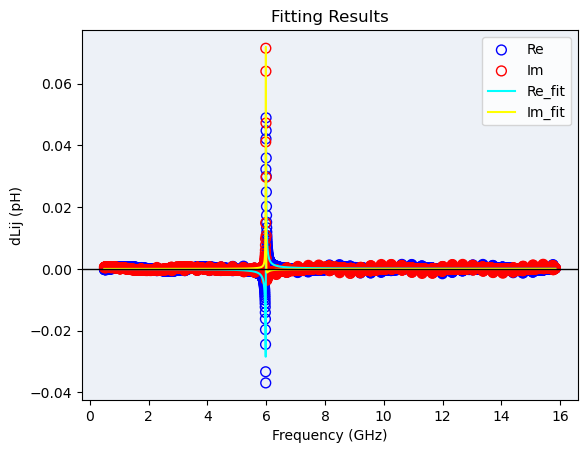


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.530e-04      1.469e-06         U        No
Ai                     8.838e-05      1.469e-06         U        No
fo                        5.9904      2.712e-05       GHz        No
df                        0.0048      2.712e-05       GHz        No
re0                   -1.580e-05      6.811e-06         U        No
im0                   -6.683e-05      6.811e-06         U        No
----------------------------------------------------------------------
Guide freq.=5.438147329705046
70


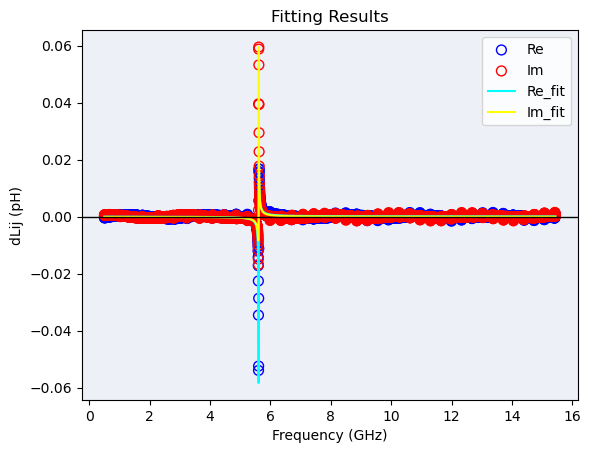


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.712e-04      1.451e-06         U        No
Ai                    -2.266e-04      1.451e-06         U        No
fo                        5.6094      2.879e-05       GHz        No
df                        0.0050      2.879e-05       GHz        No
re0                    5.264e-05      6.676e-06         U        No
im0                   -6.216e-05      6.676e-06         U        No
----------------------------------------------------------------------
Guide freq.=5.047360029372938
71


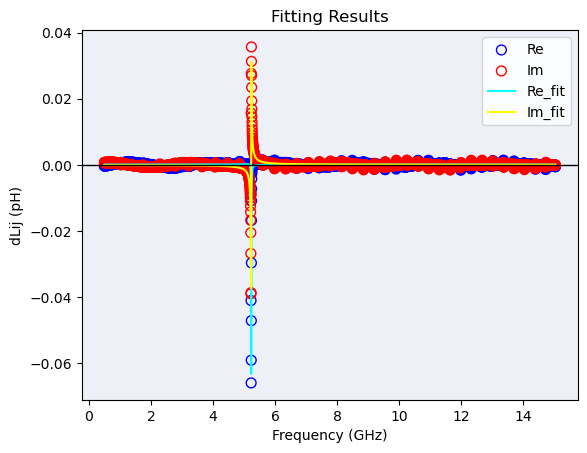


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.658e-05      1.440e-06         U        No
Ai                    -3.237e-04      1.440e-06         U        No
fo                        5.2332      2.952e-05       GHz        No
df                        0.0047      2.952e-05       GHz        No
re0                    8.687e-05      6.891e-06         U        No
im0                   -1.158e-05      6.891e-06         U        No
----------------------------------------------------------------------
Guide freq.=4.6508032810740465
72


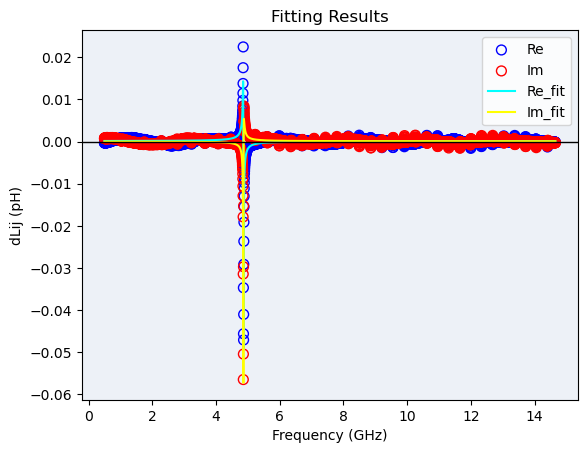


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.456e-04      1.423e-06         U        No
Ai                    -1.634e-04      1.423e-06         U        No
fo                        4.8603      3.145e-05       GHz        No
df                        0.0046      3.145e-05       GHz        No
re0                    7.218e-05      6.978e-06         U        No
im0                    4.187e-05      6.978e-06         U        No
----------------------------------------------------------------------
Guide freq.=4.233400942108806
73


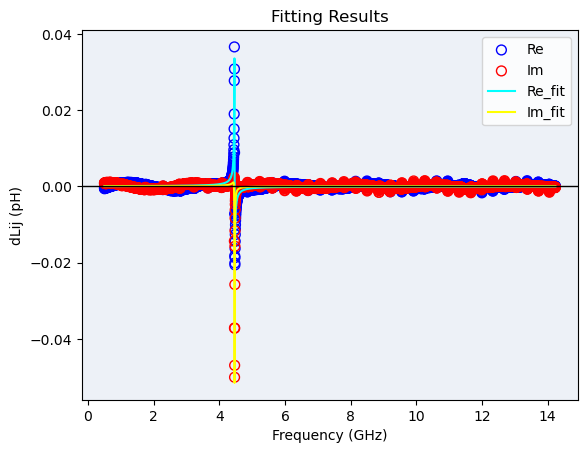


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.645e-04      1.510e-06         U        No
Ai                     7.433e-05      1.510e-06         U        No
fo                        4.4622      3.944e-05       GHz        No
df                        0.0051      3.944e-05       GHz        No
re0                    2.535e-05      7.158e-06         U        No
im0                    6.411e-05      7.158e-06         U        No
----------------------------------------------------------------------
Guide freq.=3.8299950253570665
74


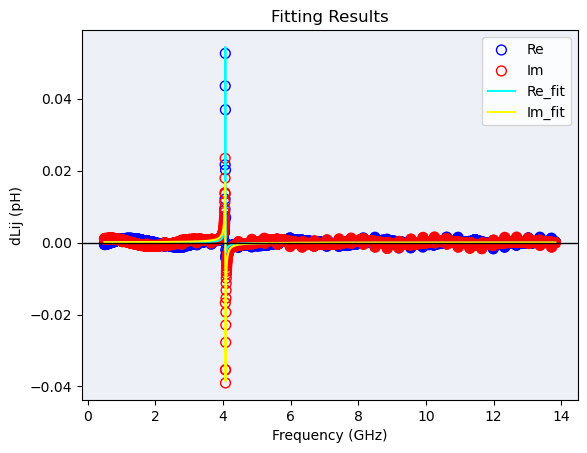


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.093e-04      1.530e-06         U        No
Ai                     2.388e-04      1.530e-06         U        No
fo                        4.0741      3.781e-05       GHz        No
df                        0.0046      3.781e-05       GHz        No
re0                   -2.018e-05      7.752e-06         U        No
im0                    4.416e-05      7.752e-06         U        No
----------------------------------------------------------------------
Guide freq.=3.4242835045482147
75


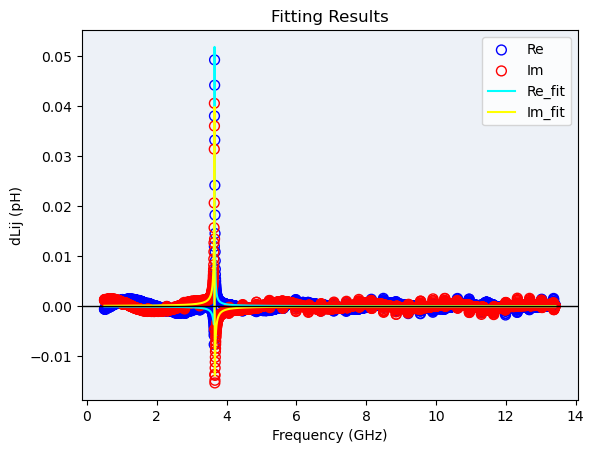


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.324e-04      1.669e-06         U        No
Ai                     2.327e-04      1.669e-06         U        No
fo                        3.6546      4.243e-05       GHz        No
df                        0.0048      4.243e-05       GHz        No
re0                   -3.461e-05      8.378e-06         U        No
im0                   -8.787e-06      8.378e-06         U        No
----------------------------------------------------------------------
Guide freq.=2.9969398352166663
76


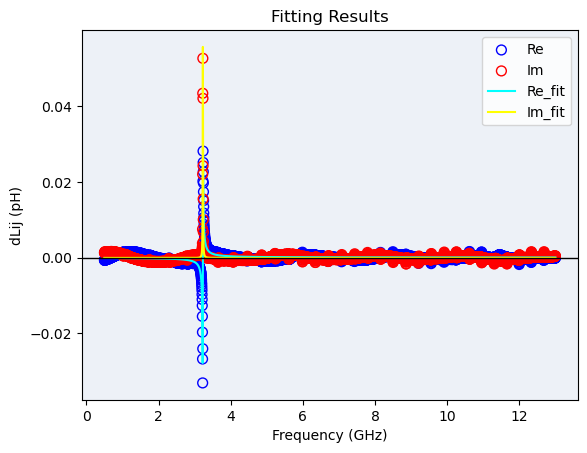


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.699e-04      1.771e-06         U        No
Ai                    -3.421e-06      1.771e-06         U        No
fo                        3.2273      4.494e-05       GHz        No
df                        0.0048      4.494e-05       GHz        No
re0                    5.740e-06      9.010e-06         U        No
im0                   -7.524e-05      9.010e-06         U        No
----------------------------------------------------------------------
Guide freq.=2.5749079777422432
77


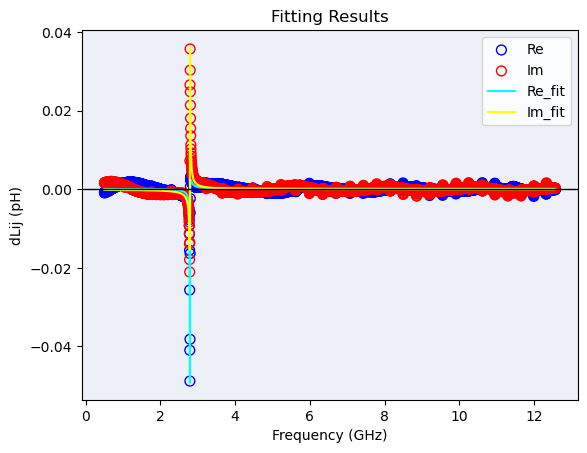


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.097e-04      2.002e-06         U        No
Ai                    -2.450e-04      2.002e-06         U        No
fo                        2.7892      5.434e-05       GHz        No
df                        0.0052      5.434e-05       GHz        No
re0                    9.416e-05      1.005e-05         U        No
im0                   -6.817e-05      1.005e-05         U        No
----------------------------------------------------------------------
Guide freq.=2.1041236579201072
78


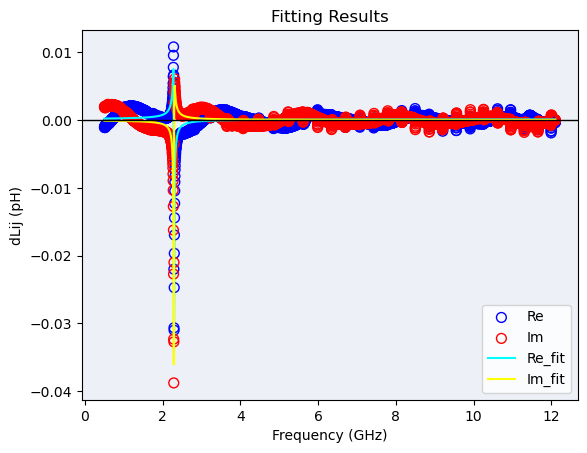


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.946e-04      2.501e-06         U        No
Ai                    -1.654e-04      2.501e-06         U        No
fo                        2.2871      8.322e-05       GHz        No
df                        0.0060      8.322e-05       GHz        No
re0                    1.391e-04      1.184e-05         U        No
im0                    1.528e-05      1.184e-05         U        No
----------------------------------------------------------------------
Guide freq.=1.5774394346276261
79


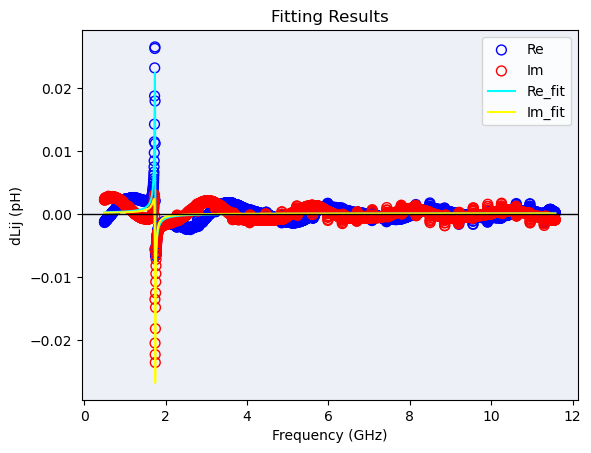


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.138e-04      3.623e-06         U        No
Ai                     1.351e-04      3.623e-06         U        No
fo                        1.7443      1.735e-04       GHz        No
df                        0.0086      1.735e-04       GHz        No
re0                    1.073e-04      1.468e-05         U        No
im0                    1.094e-04      1.468e-05         U        No
----------------------------------------------------------------------
Guide freq.=0.8561023597079105
80


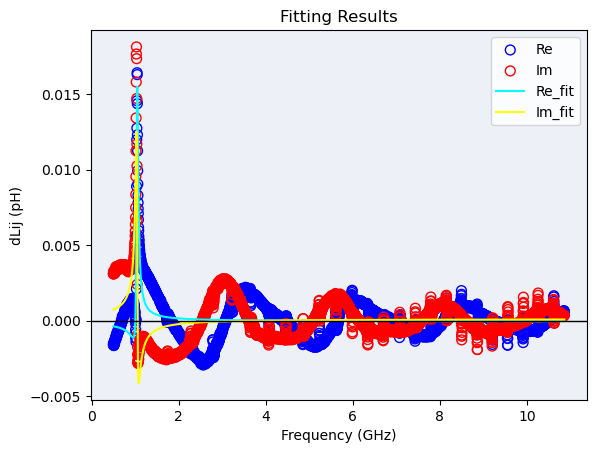


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.866e-04      7.649e-06         U        No
Ai                     3.303e-04      7.649e-06         U        No
fo                        1.0441      6.399e-04       GHz        No
df                        0.0227      6.399e-04       GHz        No
re0                   -6.102e-05      1.947e-05         U        No
im0                    1.063e-04      1.947e-05         U        No
----------------------------------------------------------------------


In [243]:
est_gamma = 28.8 #GHz/T
est_hx = 0.140 #T
est_hy = 0.00 #T

for i in range(len(ansy1.curr)):
    H_index = i
    freq = res_func.kittel_general(ansy1.calc_field("inP")[H_index],est_gamma, est_hx, est_hy)
    print(f"Guide freq.={freq}")
    print(H_index)
    ini_vals = [1, 1, freq, 0.01, 0, 0] #A, w, fres, fper, fref, re0, im0

    
    f_min, f_max = freq-10, freq+10 #GHz
    f_array = ansy1.freqs
    y_array_re, y_array_im = ansy1.d_S("21R")[H_index], ansy1.d_S("21I")[H_index]
    
    model = models.ComplexLorentzian_freq()
    fitter = fits.ComplexFitter( ini_vals, f_min, f_max,
        f_array, y_array_re , y_array_im, model)
    fitter.fix(fo=freq, df=0.01, re0=0, im0=0) # Parameters to be fixed, empty otherwise
    opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'
    #print(opt_p0)
    #fitter.plot_fit_simplex_wpm()
    new_p0 = np.array(list(opt_p0.values()), dtype=float)
    fitter.update_p0(new_p0)
    
    params, cov = fitter.fit(simplex_b=False)
    fitter.plot_fit()
    fitter.summary()
    fit_dict = fitter.export_fit_dict()
    fits_storage.save(index=H_index,field=float(ansy1.calc_field("inP")[H_index]),fit_dict=fit_dict)

In [ ]:
#Realoading parameters

In [315]:
data_L_fits = fits_storage.load_fit_results(newFile, group="Lorentzian fitting")

In [316]:
#Plotting of fitted parameters

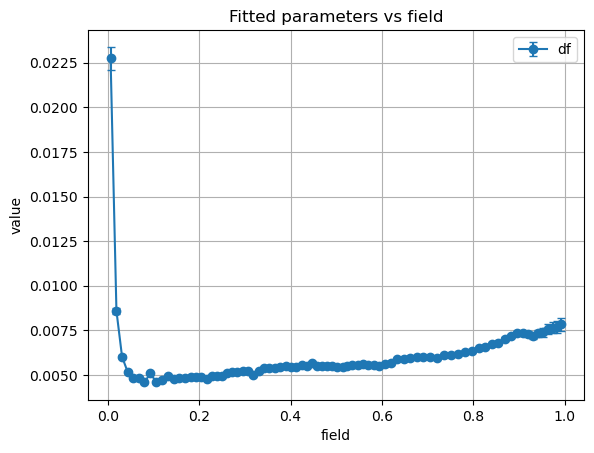

In [318]:
fits_storage.plot_fit_parameters(data_L_fits, x_axis="field", params=["df"])


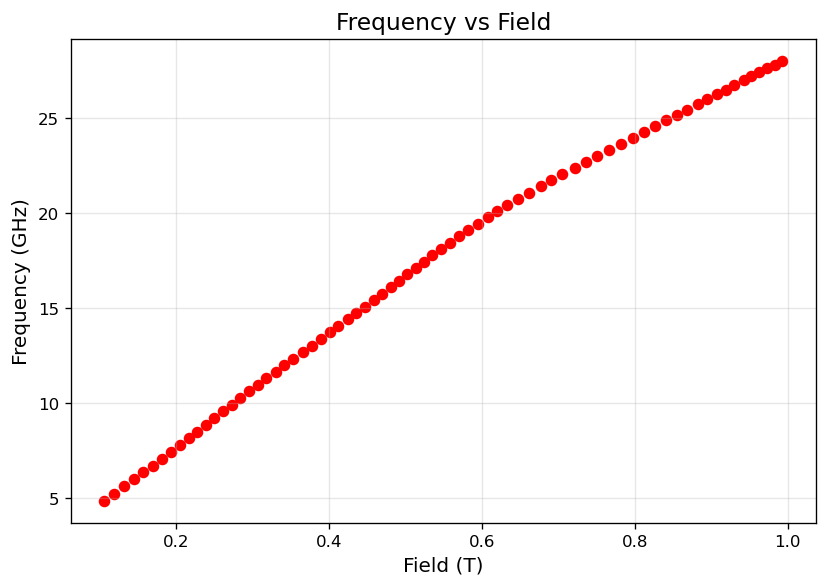

In [319]:
H = data_L_fits['field'][:-8]
fres = data_L_fits['fo'][:-8]

plt.figure(figsize=(7,5), dpi=120)

plt.scatter(H, fres, s=35, color="r")

plt.xlabel('Field (T)', fontsize=12)
plt.ylabel('Frequency (GHz)', fontsize=12)
plt.title('Frequency vs Field', fontsize=14)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

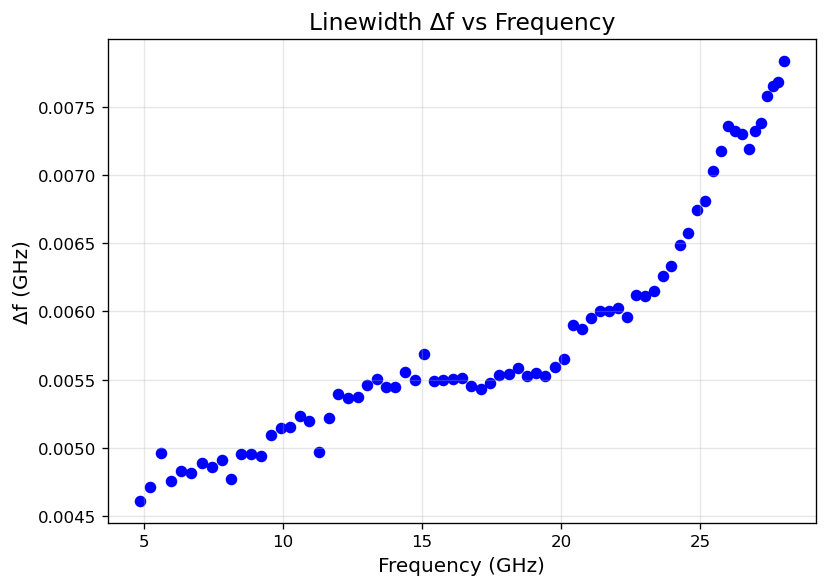

In [320]:
fres = data_L_fits['fo'][:-8]
df =  data_L_fits['df'][:-8]
plt.figure(figsize=(7,5), dpi=120)

plt.scatter(fres, df, s=35, color="b")

plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('Δf (GHz)', fontsize=12)
plt.title('Linewidth Δf vs Frequency', fontsize=14)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [321]:
gamma = 28.8   # GHz/T
Hx = 0.145     # T
Hy = 0.0       # T

# --- raw fitted data ---
H_raw  = data_L_fits['field']
f_raw  = data_L_fits['fo']
df_raw = data_L_fits['df']

# --- remove bad low-field fits ---
H  = H_raw[:-8]
f  = f_raw[:-8]


# --- linewidth conversion (Kittel-derived expression) ---
#dH = (2 * f * df) / (gamma * (2 * H + Hx + Hy)) (had to divide df by 2)
dH = (f * df) / (gamma * (2 * H + Hx + Hy))
# store it back for later reuse
data_L_fits['dH'] = dH

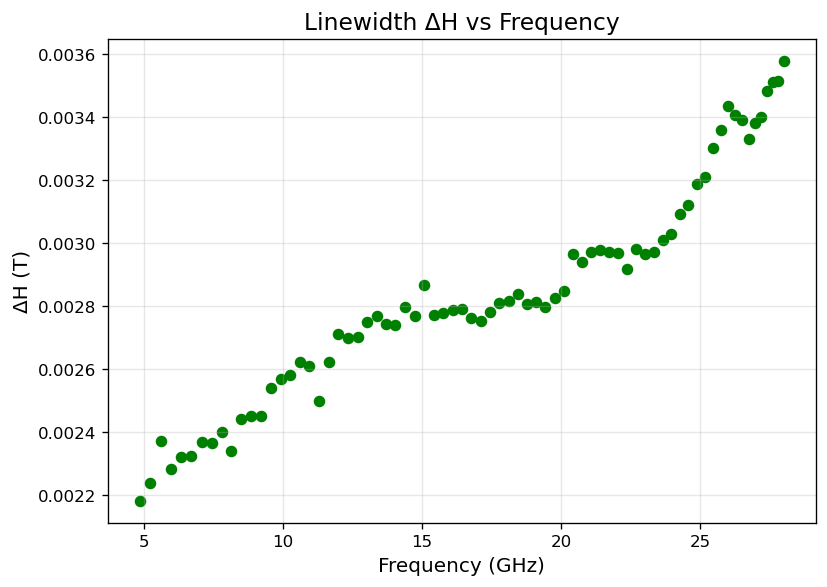

In [322]:
fres = data_L_fits['fo'][:-8]

plt.figure(figsize=(7,5), dpi=120)

plt.scatter(fres, dH, s=35, color="g")

plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('ΔH (T)', fontsize=12)
plt.title('Linewidth ΔH vs Frequency', fontsize=14)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [323]:
from scipy.stats import linregress
# Linear fit of dH vs frequency
fit = linregress(f, dH)

slope = fit.slope
intercept = fit.intercept
r2 = fit.rvalue**2

# Gilbert damping
alpha = slope * gamma / 2

print(f"Slope = {slope:.6e} T/GHz")
print(f"ΔH0 = {intercept:.6e} T")
print(f"R² = {r2:.6f}")
print(f"α = {alpha:.6e}")

Slope = 4.776242e-05 T/GHz
ΔH0 = 2.019868e-03 T
R² = 0.925100
α = 6.877788e-04


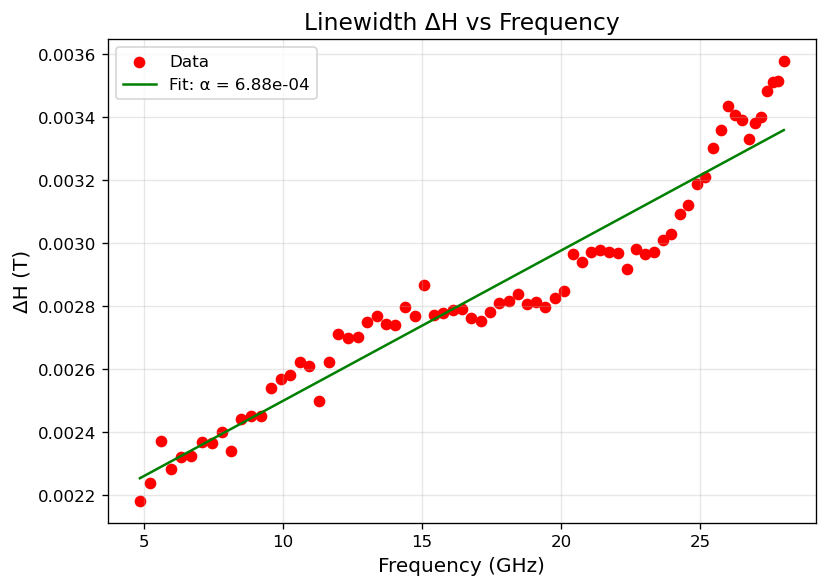

In [324]:
f_fit = np.linspace(f.min(), f.max(), 500)
dH_fit = slope*f_fit + intercept

plt.figure(figsize=(7,5), dpi=120)

plt.scatter(f, dH, label="Data", color="r")
plt.plot(f_fit, dH_fit,
         label=f"Fit: α = {alpha:.2e}", color = "g")

plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('ΔH (T)', fontsize=12)
plt.title('Linewidth ΔH vs Frequency', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()


In [63]:
print(f[:10])
print(dH[:10])

[28.04460875 27.85374065 27.6549232  27.44377105 27.23488812 27.01828369
 26.7807875  26.54074004 26.29660205 26.03011832]
[0.00874993 0.00871039 0.00862562 0.00847956 0.00838784 0.00823056
 0.00815121 0.00812637 0.0081504  0.00823621]


In [64]:
print(f[-10:])
print(dH[-10:])

[8.1674646  7.80863115 7.44976218 7.09033697 6.71915701 6.3619012
 6.00201038 5.61903355 5.24237092 4.86909475]
[0.0040315  0.00489182 0.003798   0.0037011  0.00362978 0.00377763
 0.00365197 0.00345557 0.00327142 0.0034705 ]


In [ ]:
#Fitting f. resonance vs H to the Kittel model

In [217]:
H_data= data_L_fits["field"]
f_data= data_L_fits["fo"]

gamma_fix = True
gamma_fixed = 28.8

if gamma_fix:
    function = lambda H, Hx, Hy: res_func.kittel_general(H, gamma_fixed, Hx, Hy)
    p0 = [2.18, 0.04]  # initial guess: gamma ~ 28 GHz/T (electron-like)
    lower_bounds = [ 1.8, -1.0]
    upper_bounds = [2.5,  0.2]
else:
    function = res_func.kittel_general
    p0 = [28.8, 2.18, 0.04]  # initial guess: gamma ~ 28 GHz/T (electron-like)
    lower_bounds = [28.2, 1.8, -1.0]
    upper_bounds = [29.2,  2.5,  0.2]
    
popt, pcov = curve_fit(
    function,
    H_data,
    f_data,
    p0=p0,
    bounds=(lower_bounds, upper_bounds)
)


perr = np.sqrt(np.diag(pcov))  # 1-sigma errors

H_fit = np.linspace(H_data.min(), H_data.max(), 200)
if gamma_fix:
    Hx_fit, Hy_fit = popt
    f_fit = res_func.kittel_general(H_fit, gamma_fixed, Hx_fit, Hy_fit)
    gamma_fit=gamma_fixed
else:
    gamma_fit, Hx_fit, Hy_fit = popt
    f_fit = res_func.kittel_general(H_fit, gamma_fit, Hx_fit, Hy_fit)

plt.scatter(H_data, f_data, label="Resoance f.")

plt.plot(H_fit, f_fit, label="Kittel fit", color="red")

plt.xlabel("H (T)")
plt.ylabel("Frequency (GHz)")
plt.legend()
plt.show()
print(f"gamma={gamma_fit}GHz/T, Hx={Hx_fit}T, Hy={Hy_fit}T")

C:\Users\840 G5\OneDrive - Higher Education Commission\Documents\GitHub\VNA_analysis\resonance_functions.py:81: RuntimeWarning:

invalid value encountered in sqrt



RuntimeError: Optimal parameters not found: The maximum number of function evaluations is exceeded.